In [1]:
import pyodbc
import pandas as pd
from pycaret.classification import setup, compare_models
import numpy as np

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"        # default instance
    "DATABASE=LOAN_PORTFOLIO_DB;"
    "Trusted_Connection=yes"   # use Windows Authentication
)

In [3]:
customer_df = pd.read_sql("SELECT * FROM CUSTOMER_DETAILS", conn)
account_df = pd.read_sql("SELECT * FROM ACCOUNT_DETAILS", conn)
transaction_df = pd.read_sql("SELECT * FROM TRANSACTION_DETAILS", conn)
loan_cashflow_df = pd.read_sql("SELECT * FROM LOAN_CASHFLOW", conn)
repayment_df = pd.read_sql("SELECT * FROM REPAYMENT", conn)

Exploratory Data Analysis

In [4]:
# Number of rows & columns
print(customer_df.shape, account_df.shape, transaction_df.shape)



(2509, 17) (8520, 17) (363336, 7)


In [5]:
# # Columns and types
# print(customer_df.dtypes)
# print(account_df.dtypes)

# # Quick info summary
# customer_df.info()
# account_df.info()

In [6]:
# Missing values
customer_df.isnull().sum()


MASKED_ID               0
NAME_MASKED_ID          0
AGE                     0
GENDER                  0
CUSTOMER_RISK           2
CUSTOMER_RISK_NAME      0
OCCUPATION              1
DISTRICT                3
TARGET_CODE             0
TARGET_DESC             0
MARITAL_STATUS        549
DATE_OF_BIRTH           0
EMPLOYMENT_STATUS      12
MASKED_LEGAL_ID         0
LEGAL_DOC_NAME          0
INDUSTRY_CODE           0
INDUSTRY                0
dtype: int64

In [7]:
customer_df['MARITAL_STATUS'].fillna('Unknown', inplace=True)
customer_df['EMPLOYMENT_STATUS'].fillna('Unknown', inplace=True)
customer_df['DISTRICT'].fillna('Unknown', inplace=True)
customer_df['OCCUPATION'].fillna('Unknown', inplace=True)
median_risk = customer_df['CUSTOMER_RISK'].median()
customer_df['CUSTOMER_RISK'].fillna(median_risk, inplace=True)
# chcking after replacing the Missing values
customer_df.isnull().sum()

MASKED_ID             0
NAME_MASKED_ID        0
AGE                   0
GENDER                0
CUSTOMER_RISK         0
CUSTOMER_RISK_NAME    0
OCCUPATION            0
DISTRICT              0
TARGET_CODE           0
TARGET_DESC           0
MARITAL_STATUS        0
DATE_OF_BIRTH         0
EMPLOYMENT_STATUS     0
MASKED_LEGAL_ID       0
LEGAL_DOC_NAME        0
INDUSTRY_CODE         0
INDUSTRY              0
dtype: int64

In [8]:
account_df.isnull().sum()


MASKED_ID                        0
ACC_MASKED_ID                    0
TERM                          3722
TERM_AMOUNT                   4157
OOD                           7925
ACTIVE_PRODUCT                   0
ORIG_CONTRACT_DATE               0
ACCT_CLOSE_DATE               5286
ACCT_STATUS                      0
MONTHEND_CONVERTED_BALANCE    3653
CONVERTED_BALANCE             3604
JUN_25                        3612
JUL_25                        3660
AUG_25                        3677
SEP_25                        3662
OCT_25                        3602
NOV_25                        3495
dtype: int64

In [9]:
accts_numeric_cols = ['TERM', 'TERM_AMOUNT', 'OOD', 'MONTHEND_CONVERTED_BALANCE', 'CONVERTED_BALANCE',
                'JUN_25','JUL_25','AUG_25','SEP_25','OCT_25','NOV_25']

account_df[accts_numeric_cols] = account_df[accts_numeric_cols].fillna(0)

account_df['ACCT_CLOSE_DATE'] = pd.to_datetime(account_df['ACCT_CLOSE_DATE'], errors='coerce')

#checking after filling with 0
account_df.isnull().sum()

MASKED_ID                        0
ACC_MASKED_ID                    0
TERM                             0
TERM_AMOUNT                      0
OOD                              0
ACTIVE_PRODUCT                   0
ORIG_CONTRACT_DATE               0
ACCT_CLOSE_DATE               5286
ACCT_STATUS                      0
MONTHEND_CONVERTED_BALANCE       0
CONVERTED_BALANCE                0
JUN_25                           0
JUL_25                           0
AUG_25                           0
SEP_25                           0
OCT_25                           0
NOV_25                           0
dtype: int64

In [10]:
# Missing values
transaction_df.isnull().sum()

MASK_TRAN_REF       0
ACC_MASKED_ID       0
MASKED_ID           0
AMOUNT_LCY          0
TRANSACTION_CODE    0
TRAN_NARRATIVE      0
BOOKING_DATE        0
dtype: int64

In [11]:
# Missing values
loan_cashflow_df.isnull().sum()



MASKED_ID                  0
ACC_MASKED_ID              0
TERM                       0
TERM_AMOUNT                0
OOD                     1509
TO_BE_PAYMENT_DATE       769
CAPITAL_TO_BE_PAIED     1243
INTEREST_TO_BE_PAIED    1033
dtype: int64

In [12]:
loan_numeric_cols = ['OOD', 'CAPITAL_TO_BE_PAIED', 'INTEREST_TO_BE_PAIED']
loan_cashflow_df[loan_numeric_cols] = loan_cashflow_df[loan_numeric_cols].fillna(0)

loan_cashflow_df['TO_BE_PAYMENT_DATE'] = pd.to_datetime(loan_cashflow_df['TO_BE_PAYMENT_DATE'], errors='coerce')

#checking after filling with 0
loan_cashflow_df.isnull().sum()

MASKED_ID                 0
ACC_MASKED_ID             0
TERM                      0
TERM_AMOUNT               0
OOD                       0
TO_BE_PAYMENT_DATE      769
CAPITAL_TO_BE_PAIED       0
INTEREST_TO_BE_PAIED      0
dtype: int64

In [13]:
repayment_df.isnull().sum()

MASKED_ID           0
ACC_MASKED_ID       0
TERM                0
TERM_AMOUNT         0
OOD               895
PAYMENT_DATE        0
CAPITAL_PAIED     996
INTEREST_PAIED      0
dtype: int64

In [14]:
repayment_numeric_cols = ['OOD', 'CAPITAL_PAIED']
repayment_df[repayment_numeric_cols] = repayment_df[repayment_numeric_cols].fillna(0)

#checking after filling with 0
repayment_df.isnull().sum()

MASKED_ID         0
ACC_MASKED_ID     0
TERM              0
TERM_AMOUNT       0
OOD               0
PAYMENT_DATE      0
CAPITAL_PAIED     0
INTEREST_PAIED    0
dtype: int64

In [15]:
# Numeric features summary
customer_df.describe()


,AGE,CUSTOMER_RISK,TARGET_CODE,INDUSTRY_CODE
count,2509.000000,2509.000000,2509.000000,2.509000e+03
mean,39.261459,1.206855,968.976485,9.902043e+09
std,13.318699,0.446340,31.295191,3.541747e+07
min,19.000000,1.000000,908.000000,9.808089e+09
25%,29.000000,1.000000,948.000000,9.898990e+09
50%,37.000000,1.000000,988.000000,9.918589e+09
75%,47.000000,1.000000,988.000000,9.918689e+09
max,99.000000,4.000000,988.000000,9.998989e+09


In [16]:
account_df.describe()


,TERM_AMOUNT,OOD,MONTHEND_CONVERTED_BALANCE,CONVERTED_BALANCE,JUN_25,JUL_25,AUG_25,SEP_25,OCT_25,NOV_25
count,8.520000e+03,8520.000000,8.520000e+03,8.520000e+03,8.520000e+03,8.520000e+03,8.520000e+03,8.520000e+03,8.520000e+03,8.520000e+03
mean,1.062962e+06,7.656221,1.921945e+05,1.881938e+05,2.265484e+05,2.168875e+05,2.017722e+05,2.091888e+05,2.048603e+05,2.000455e+05
std,3.114658e+06,138.285123,2.205214e+06,2.299325e+06,2.087131e+06,2.168561e+06,2.077367e+06,2.227227e+06,2.200615e+06,2.335337e+06
min,0.000000e+00,0.000000,-2.962159e+07,-3.043514e+07,-3.044330e+07,-3.030347e+07,-3.015907e+07,-3.002555e+07,-2.988066e+07,-2.973503e+07
25%,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.200000e+04,0.000000,0.000000e+00,1.690000e+00,2.959000e+01,1.837500e+01,1.004500e+01,1.352000e+01,2.722500e+01,4.272000e+01
75%,9.000000e+05,0.000000,1.922365e+04,1.827875e+04,2.196253e+04,2.176802e+04,2.230652e+04,2.080432e+04,2.245909e+04,2.446152e+04
max,6.700000e+07,5583.000000,7.477982e+07,7.497982e+07,5.720000e+07,5.720000e+07,5.720000e+07,5.903759e+07,5.722076e+07,7.288775e+07


In [17]:
transaction_df.describe()


,MASK_TRAN_REF,AMOUNT_LCY,TRANSACTION_CODE
count,3.633360e+05,3.633360e+05,363336.000000
mean,9.592260e+13,-2.314393e+04,5212.762424
std,5.030241e+12,6.112910e+05,3867.730394
min,8.720003e+13,-7.500000e+07,2.000000
25%,8.777293e+13,-1.013938e+04,797.000000
50%,9.856697e+13,-1.500000e+03,8005.000000
75%,9.914926e+13,-1.500000e+01,9001.000000
max,9.999999e+13,6.717254e+07,9040.000000


In [18]:
repayment_df.describe()

,CAPITAL_PAIED
count,4.300000e+03
mean,1.039675e+05
std,6.962388e+05
min,-3.049458e+05
25%,9.322500e+00
50%,6.508995e+03
75%,3.186757e+04
max,2.500000e+07


In [19]:
loan_cashflow_df.describe()

,MASKED_ID,ACC_MASKED_ID,TERM,TERM_AMOUNT,OOD,TO_BE_PAYMENT_DATE,CAPITAL_TO_BE_PAIED,INTEREST_TO_BE_PAIED
count,4631,4631,4631,4631,4631,3862,4631.0,4631.0
unique,454,1461,589,503,63,243,2851.0,3307.0
top,9880626,BB038019JWYK,12M,500000,0,2025-11-25 00:00:00,0.0,0.0
freq,117,25,200,203,2602,212,1243.0,1033.0
first,NaN,NaN,NaN,NaN,NaN,2025-05-01 00:00:00,NaN,NaN
last,NaN,NaN,NaN,NaN,NaN,2025-12-31 00:00:00,NaN,NaN


In [20]:

# Categorical features summary
customer_df.select_dtypes(include='object').nunique()


MASKED_ID             2509
NAME_MASKED_ID        2509
GENDER                   2
CUSTOMER_RISK_NAME       5
OCCUPATION              77
DISTRICT                25
TARGET_DESC              5
MARITAL_STATUS           3
DATE_OF_BIRTH         2334
EMPLOYMENT_STATUS        8
MASKED_LEGAL_ID       2509
LEGAL_DOC_NAME           4
INDUSTRY                94
dtype: int64

In [21]:
account_df.select_dtypes(include='object').nunique()

MASKED_ID             2508
ACC_MASKED_ID         8520
TERM                   744
ACTIVE_PRODUCT           5
ORIG_CONTRACT_DATE    2438
ACCT_STATUS              6
dtype: int64

In [22]:
loan_cashflow_df.select_dtypes(include='object').nunique()

MASKED_ID                454
ACC_MASKED_ID           1461
TERM                     589
TERM_AMOUNT              503
OOD                       63
CAPITAL_TO_BE_PAIED     2851
INTEREST_TO_BE_PAIED    3307
dtype: int64

In [23]:
repayment_df.select_dtypes(include='object').nunique()

MASKED_ID          312
ACC_MASKED_ID      655
TERM               371
TERM_AMOUNT        289
OOD                 50
PAYMENT_DATE       233
INTEREST_PAIED    3420
dtype: int64

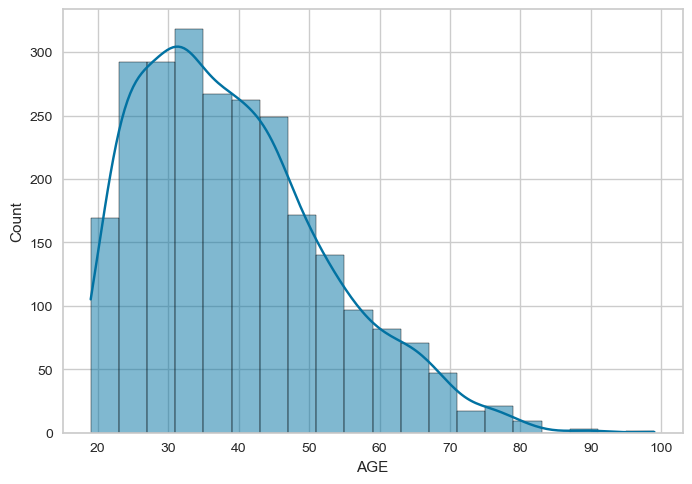

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: AGE distribution
sns.histplot(customer_df['AGE'], bins=20, kde=True)
plt.show()



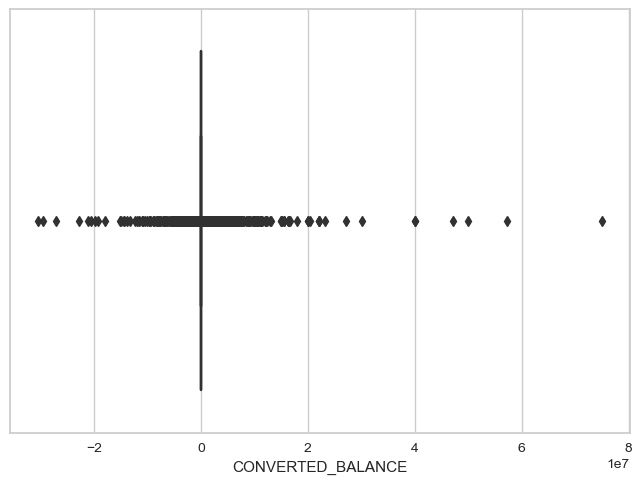

In [25]:
# Account balances
sns.boxplot(x=account_df['CONVERTED_BALANCE'])
plt.show()

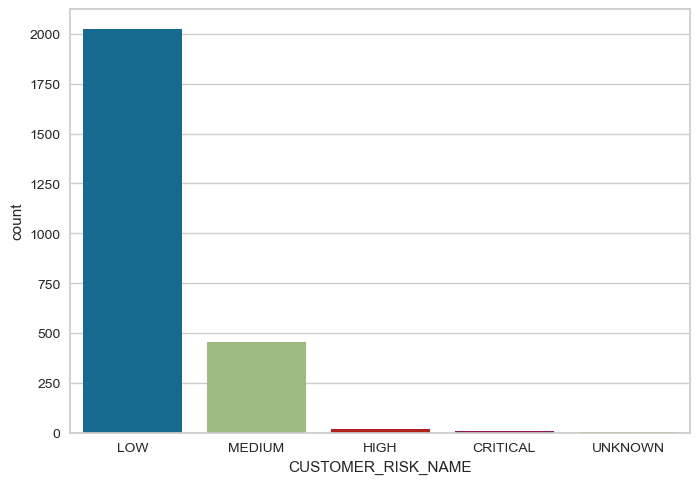

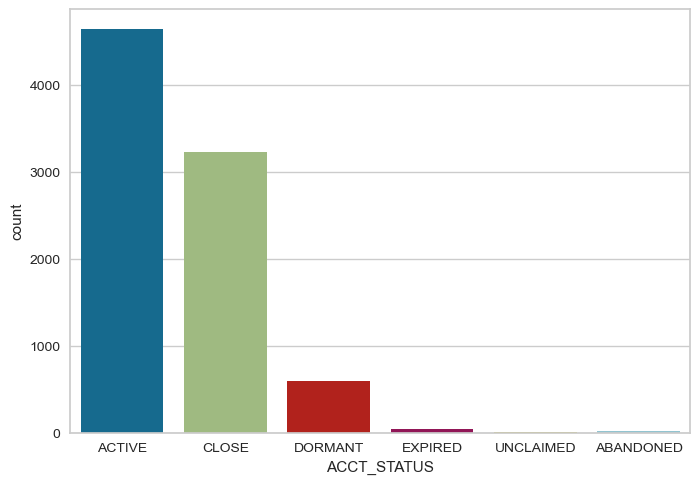

In [26]:
# Count of customers by risk
sns.countplot(x='CUSTOMER_RISK_NAME', data=customer_df)
plt.show()

# Account status
sns.countplot(x='ACCT_STATUS', data=account_df)
plt.show()

In [27]:
account_df

,MASKED_ID,ACC_MASKED_ID,TERM,TERM_AMOUNT,OOD,ACTIVE_PRODUCT,ORIG_CONTRACT_DATE,ACCT_CLOSE_DATE,ACCT_STATUS,MONTHEND_CONVERTED_BALANCE,CONVERTED_BALANCE,JUN_25,JUL_25,AUG_25,SEP_25,OCT_25,NOV_25
0,000454,BB00106DV0L7,0,0.0,0.0,SAVINGS ACCOUNT,2022-11-24,NaT,ACTIVE,4.207961e+05,1.761807e+04,5.816745e+04,7.188120e+04,1.290630e+03,1.952680e+03,1.506377e+04,2.226882e+05
1,000454,BB00106F1DX0,60M,500000.0,0.0,FIXED DEPOSIT ACCOUNT,2022-11-24,NaT,ACTIVE,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05
2,000454,BB00106L3ZVN,1097D,400000.0,0.0,LOAN ACCOUNT,2022-11-24,2025-12-03,CLOSE,0.000000e+00,0.000000e+00,-6.444448e+04,-5.304663e+04,-4.322869e+04,-3.287300e+04,-2.233317e+04,-1.130280e+04
3,000454,BB00133NSWRT,369D,2375000.0,0.0,LOAN ACCOUNT,2022-12-21,2023-11-10,CLOSE,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,000454,BB00138PNPFT,60M,2500000.0,0.0,FIXED DEPOSIT ACCOUNT,2022-12-16,NaT,ACTIVE,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8515,9998721,BB09079RPQ53,0,0.0,0.0,SAVINGS ACCOUNT,2014-06-30,NaT,ACTIVE,3.654700e+02,9.254700e+02,2.586855e+04,2.701799e+04,3.078505e+04,4.528308e+04,2.068335e+04,8.629330e+03
8516,9999535,BB02118R8W32,0,0.0,0.0,SAVINGS ACCOUNT,2024-11-25,NaT,ACTIVE,8.833616e+04,8.211600e+02,1.016601e+05,1.156048e+06,5.234788e+04,6.728861e+04,1.164431e+05,1.327792e+05
8517,9999535,BB09079FWV46,0,0.0,0.0,SAVINGS ACCOUNT,2014-07-18,NaT,ACTIVE,7.789401e+05,2.758661e+05,1.404001e+04,6.464130e+03,1.243665e+05,7.613335e+04,2.626008e+05,8.083205e+05
8518,9999658,BB09079VJS24,0,0.0,0.0,SAVINGS ACCOUNT,2014-04-30,NaT,ACTIVE,5.454049e+04,4.559549e+04,5.743928e+04,6.547739e+04,7.128710e+04,7.698738e+04,7.129555e+04,4.570675e+04


In [28]:
customer_df

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,MARITAL_STATUS,DATE_OF_BIRTH,EMPLOYMENT_STATUS,MASKED_LEGAL_ID,LEGAL_DOC_NAME,INDUSTRY_CODE,INDUSTRY
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,MARRIED,1989-02-12,UNEMPLOYED,673211788H,NIC,9908088888,HEALTH & SOCIAL-OTHER SOCIAL SERVICES
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,SINGLE,1998-04-19,EMPLOYED,764988120H,NIC,9848688888,"TRADE-GARMENTS, CULTURAL AND RECREATION GOODS"
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,Unknown,1984-03-22,EMPLOYED,623608269H,NIC,9908088888,HEALTH & SOCIAL-OTHER SOCIAL SERVICES
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,Unknown,2000-03-23,EMPLOYED,088836189142,EIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,MARRIED,1964-09-07,UNEMPLOYED,425399959W,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2504,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,SINGLE,1986-06-08,EMPLOYED,644488129H,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...
2505,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,SINGLE,1991-04-21,BUSINESS,799900186H,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...
2506,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,MARRIED,1980-06-22,SELF-EMPLOYED,976895289567,EIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...
2507,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,MARRIED,1996-04-30,SELF-EMPLOYED,744098515H,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...


# Rule 1 - Hard Eligibility & Regulatory Rules

## Regulatory Age Check

In [29]:
customer_df['Eligibility_Flag'] = 'ELIGIBLE'
customer_df['Rejection_Reason'] = None

In [30]:
customer_df.loc[
    (customer_df['AGE'] < 18) | (customer_df['AGE'] > 80),
    ['Eligibility_Flag', 'Rejection_Reason']
] = ['REJECT', 'Regulatory Age Restriction']


In [31]:
customer_df[customer_df['Eligibility_Flag'] == 'REJECT'][['AGE', 'Eligibility_Flag', 'Rejection_Reason']]


,AGE,Eligibility_Flag,Rejection_Reason
1342,88,REJECT,Regulatory Age Restriction
1394,90,REJECT,Regulatory Age Restriction
1912,90,REJECT,Regulatory Age Restriction
2015,99,REJECT,Regulatory Age Restriction
2124,81,REJECT,Regulatory Age Restriction
2160,82,REJECT,Regulatory Age Restriction
2369,82,REJECT,Regulatory Age Restriction


In [32]:
customer_df['Eligibility_Flag'].value_counts()


ELIGIBLE    2502
REJECT         7
Name: Eligibility_Flag, dtype: int64

In [33]:
eligible_cus_df = customer_df[customer_df['Eligibility_Flag'] == 'ELIGIBLE'].copy()


## Account Eligibility Check

In [34]:
active_accounts = account_df[
    (account_df['ACCT_STATUS'] == 'ACTIVE') |
    (account_df['ACCT_CLOSE_DATE'].isna())
]

active_account_count = (
    active_accounts
    .groupby('MASKED_ID')
    .size()
    .reset_index(name='Number_of_Active_Accounts')
)

In [35]:
eligible_cus_df = eligible_cus_df.merge(
    active_account_count,
    on='MASKED_ID',
    how='left'
)

In [36]:

# if no accounts isnted of Nan use 0 
eligible_cus_df['Number_of_Active_Accounts'] = (
    eligible_cus_df['Number_of_Active_Accounts']
    .fillna(0)
    .astype(int)
)


In [37]:
# Step 1: Set ELSE condition (default)
eligible_cus_df['Eligibility_Flag'] = 'ELIGIBLE'
eligible_cus_df['Rejection_Reason'] = 'Existing Customer'

# Step 2: Apply IF condition
eligible_cus_df.loc[
    eligible_cus_df['Number_of_Active_Accounts'] == 0,
    ['Eligibility_Flag', 'Rejection_Reason']
] = ['REJECT', 'Non-Existing Customer']

In [38]:
eligible_cus_df

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,MARITAL_STATUS,DATE_OF_BIRTH,EMPLOYMENT_STATUS,MASKED_LEGAL_ID,LEGAL_DOC_NAME,INDUSTRY_CODE,INDUSTRY,Eligibility_Flag,Rejection_Reason,Number_of_Active_Accounts
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,MARRIED,1989-02-12,UNEMPLOYED,673211788H,NIC,9908088888,HEALTH & SOCIAL-OTHER SOCIAL SERVICES,ELIGIBLE,Existing Customer,5
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,SINGLE,1998-04-19,EMPLOYED,764988120H,NIC,9848688888,"TRADE-GARMENTS, CULTURAL AND RECREATION GOODS",ELIGIBLE,Existing Customer,2
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,Unknown,1984-03-22,EMPLOYED,623608269H,NIC,9908088888,HEALTH & SOCIAL-OTHER SOCIAL SERVICES,ELIGIBLE,Existing Customer,1
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,Unknown,2000-03-23,EMPLOYED,088836189142,EIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,3
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,MARRIED,1964-09-07,UNEMPLOYED,425399959W,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,SINGLE,1986-06-08,EMPLOYED,644488129H,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,1
2498,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,SINGLE,1991-04-21,BUSINESS,799900186H,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,3
2499,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,MARRIED,1980-06-22,SELF-EMPLOYED,976895289567,EIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,2
2500,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,MARRIED,1996-04-30,SELF-EMPLOYED,744098515H,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,1


In [39]:
eligible_cus_df['Number_of_Active_Accounts'].describe()

count    2502.000000
mean        2.107514
std         2.602868
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        46.000000
Name: Number_of_Active_Accounts, dtype: float64

In [40]:
eligible_cus_df['Number_of_Active_Accounts'].value_counts().sort_index()

0        9
1     1524
2      462
3      195
4       94
5       54
6       47
7       18
8       29
9        9
10      12
11      10
12      12
13       7
14       1
15       5
16       4
17       1
19       3
20       1
25       1
27       1
28       1
35       1
46       1
Name: Number_of_Active_Accounts, dtype: int64

In [41]:
# Count of eligible customers
eligible_count = eligible_cus_df[eligible_cus_df['Eligibility_Flag'] == 'ELIGIBLE'].shape[0]
print("Number of eligible customers:", eligible_count)

Number of eligible customers: 2493


In [42]:
eligible_cus_df['Eligibility_Flag'].unique()

array(['ELIGIBLE', 'REJECT'], dtype=object)

## Employment Status Validation

In [43]:
valid_employment_status = pd.read_sql(
    "SELECT DISTINCT EMPLOYMENT_STATUS FROM CUSTOMER_DETAILS",
    conn
)['EMPLOYMENT_STATUS'].dropna().tolist()

In [44]:
eligible_cus_df['Employment_Status_Flag'] = 'Valid Employment Status'

eligible_cus_df.loc[
    ~eligible_cus_df['EMPLOYMENT_STATUS'].isin(valid_employment_status),
    'Employment_Status_Flag'
] = 'Invalid Employment Status'

In [45]:
eligible_cus_df

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,...,DATE_OF_BIRTH,EMPLOYMENT_STATUS,MASKED_LEGAL_ID,LEGAL_DOC_NAME,INDUSTRY_CODE,INDUSTRY,Eligibility_Flag,Rejection_Reason,Number_of_Active_Accounts,Employment_Status_Flag
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,...,1989-02-12,UNEMPLOYED,673211788H,NIC,9908088888,HEALTH & SOCIAL-OTHER SOCIAL SERVICES,ELIGIBLE,Existing Customer,5,Valid Employment Status
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,...,1998-04-19,EMPLOYED,764988120H,NIC,9848688888,"TRADE-GARMENTS, CULTURAL AND RECREATION GOODS",ELIGIBLE,Existing Customer,2,Valid Employment Status
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,...,1984-03-22,EMPLOYED,623608269H,NIC,9908088888,HEALTH & SOCIAL-OTHER SOCIAL SERVICES,ELIGIBLE,Existing Customer,1,Valid Employment Status
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,...,2000-03-23,EMPLOYED,088836189142,EIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,3,Valid Employment Status
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,...,1964-09-07,UNEMPLOYED,425399959W,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,1,Valid Employment Status
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,...,1986-06-08,EMPLOYED,644488129H,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,1,Valid Employment Status
2498,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,...,1991-04-21,BUSINESS,799900186H,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,3,Valid Employment Status
2499,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,...,1980-06-22,SELF-EMPLOYED,976895289567,EIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,2,Valid Employment Status
2500,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,...,1996-04-30,SELF-EMPLOYED,744098515H,NIC,9918688888,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,1,Valid Employment Status


In [46]:
# Check age range
print(eligible_cus_df['AGE'].min(), eligible_cus_df['AGE'].max())

# Check active accounts
print(eligible_cus_df['Number_of_Active_Accounts'].min())

# Check employment status
print(eligible_cus_df['EMPLOYMENT_STATUS'].unique())

# Check eligibility flag
print(eligible_cus_df['Eligibility_Flag'].unique())

19 80
0
['UNEMPLOYED' 'EMPLOYED' 'SELF-EMPLOYED' 'BUSINESS' 'STUDENT' 'RETIRED'
 'FREELANCE' 'Unknown']
['ELIGIBLE' 'REJECT']


# Rule 2 - Employment-Based Routing & Participation Rules

## Routing & Participation 

In [47]:
eligible_cus_df['Employment_Segment'] = 'Other'

In [48]:
eligible_cus_df.loc[
    (eligible_cus_df['EMPLOYMENT_STATUS'].isin(['EMPLOYED', 'SELF-EMPLOYED', 'BUSINESS'])) &
    (eligible_cus_df['AGE'].between(18, 60)),
    'Employment_Segment'
] = 'Core Working Group'


In [49]:
eligible_cus_df.loc[
    (eligible_cus_df['EMPLOYMENT_STATUS'].isin(['UNEMPLOYED	', 'RETIRED', 'STUDENT', 'FREELANCE'])) &
    (eligible_cus_df['AGE'].between(18, 65)),
    'Employment_Segment'
] = 'Special Segment'

In [50]:
eligible_cus_df.loc[
    (eligible_cus_df['EMPLOYMENT_STATUS'].isin([
        'UNEMPLOYED', 'RETIRED', 'STUDENT', 'FREELANCE', 
        'EMPLOYED', 'SELF-EMPLOYED', 'BUSINESS'
    ])) &
    (~eligible_cus_df['AGE'].between(18, 60)),  # not between 18 and 60
    'Employment_Segment'
] = 'Not valid segment'

# Rule 3 - Age-Based Segments

In [51]:
eligible_cus_df['Age_Bucket'] = pd.cut(
    eligible_cus_df['AGE'],
    bins=[17, 25, 40, 60, 80],
    labels=['Young Adult', 'Adult', 'Middle-Aged', 'Senior']
)

In [52]:
eligible_cus_df['Age_Bucket'].value_counts(dropna=False)

Adult          1085
Middle-Aged     822
Young Adult     395
Senior          200
Name: Age_Bucket, dtype: int64

# Rule 4 - Financial capacity

In [53]:
balance_cols = ['JUN_25', 'JUL_25', 'AUG_25', 'SEP_25', 'OCT_25', 'NOV_25']

In [54]:
account_df['Monthly_Avg_Balance'] = account_df[balance_cols].mean(axis=1)

In [55]:
account_df

,MASKED_ID,ACC_MASKED_ID,TERM,TERM_AMOUNT,OOD,ACTIVE_PRODUCT,ORIG_CONTRACT_DATE,ACCT_CLOSE_DATE,ACCT_STATUS,MONTHEND_CONVERTED_BALANCE,CONVERTED_BALANCE,JUN_25,JUL_25,AUG_25,SEP_25,OCT_25,NOV_25,Monthly_Avg_Balance
0,000454,BB00106DV0L7,0,0.0,0.0,SAVINGS ACCOUNT,2022-11-24,NaT,ACTIVE,4.207961e+05,1.761807e+04,5.816745e+04,7.188120e+04,1.290630e+03,1.952680e+03,1.506377e+04,2.226882e+05,6.184066e+04
1,000454,BB00106F1DX0,60M,500000.0,0.0,FIXED DEPOSIT ACCOUNT,2022-11-24,NaT,ACTIVE,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05,5.000000e+05
2,000454,BB00106L3ZVN,1097D,400000.0,0.0,LOAN ACCOUNT,2022-11-24,2025-12-03,CLOSE,0.000000e+00,0.000000e+00,-6.444448e+04,-5.304663e+04,-4.322869e+04,-3.287300e+04,-2.233317e+04,-1.130280e+04,-3.787146e+04
3,000454,BB00133NSWRT,369D,2375000.0,0.0,LOAN ACCOUNT,2022-12-21,2023-11-10,CLOSE,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,000454,BB00138PNPFT,60M,2500000.0,0.0,FIXED DEPOSIT ACCOUNT,2022-12-16,NaT,ACTIVE,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06,2.500000e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8515,9998721,BB09079RPQ53,0,0.0,0.0,SAVINGS ACCOUNT,2014-06-30,NaT,ACTIVE,3.654700e+02,9.254700e+02,2.586855e+04,2.701799e+04,3.078505e+04,4.528308e+04,2.068335e+04,8.629330e+03,2.637789e+04
8516,9999535,BB02118R8W32,0,0.0,0.0,SAVINGS ACCOUNT,2024-11-25,NaT,ACTIVE,8.833616e+04,8.211600e+02,1.016601e+05,1.156048e+06,5.234788e+04,6.728861e+04,1.164431e+05,1.327792e+05,2.710945e+05
8517,9999535,BB09079FWV46,0,0.0,0.0,SAVINGS ACCOUNT,2014-07-18,NaT,ACTIVE,7.789401e+05,2.758661e+05,1.404001e+04,6.464130e+03,1.243665e+05,7.613335e+04,2.626008e+05,8.083205e+05,2.153209e+05
8518,9999658,BB09079VJS24,0,0.0,0.0,SAVINGS ACCOUNT,2014-04-30,NaT,ACTIVE,5.454049e+04,4.559549e+04,5.743928e+04,6.547739e+04,7.128710e+04,7.698738e+04,7.129555e+04,4.570675e+04,6.469891e+04


In [56]:
customer_balance_df = (
    account_df
    .groupby('MASKED_ID', as_index=False)['Monthly_Avg_Balance']
    .mean()
)


In [57]:
eligible_cus_df = eligible_cus_df.merge(
    customer_balance_df,
    on='MASKED_ID',
    how='left'
)


In [58]:
eligible_cus_df['Financial_Capacity'] = 'Unknown / Missing Balance Data'

eligible_cus_df.loc[
    eligible_cus_df['Monthly_Avg_Balance'] >= 100000,
    'Financial_Capacity'
] = 'High Financial Capacity'

eligible_cus_df.loc[
    eligible_cus_df['Monthly_Avg_Balance'].between(50000, 99999),
    'Financial_Capacity'
] = 'Medium Financial Capacity'

eligible_cus_df.loc[
    eligible_cus_df['Monthly_Avg_Balance'] < 50000,
    'Financial_Capacity'
] = 'Low Financial Capacity'


In [59]:
eligible_cus_df[['Monthly_Avg_Balance', 'Financial_Capacity']].sample(10)

,Monthly_Avg_Balance,Financial_Capacity
223,3631.893290,Low Financial Capacity
182,5120.376628,Low Financial Capacity
1952,2630.059956,Low Financial Capacity
1737,52697.328125,Medium Financial Capacity
1504,674.653330,Low Financial Capacity
2466,39640.811198,Low Financial Capacity
542,2232.453302,Low Financial Capacity
2460,1004.018331,Low Financial Capacity
33,7559.869954,Low Financial Capacity
2214,1524.734985,Low Financial Capacity


# Rule 6 - Salary Verification Check

In [60]:
transaction_df

,MASK_TRAN_REF,ACC_MASKED_ID,MASKED_ID,AMOUNT_LCY,TRANSACTION_CODE,TRAN_NARRATIVE,BOOKING_DATE
0,9.825868e+13,BB02901VMKYW,014678,118500.0,774,CRM Cash Deposit,2025-08-15
1,9.814575e+13,BB02901VMKYW,014678,75000.0,774,CRM Cash Deposit,2025-08-04
2,9.832860e+13,BB02901VMKYW,014678,3000.0,774,CRM Cash Deposit,2025-08-22
3,9.815965e+13,BB02901VMKYW,014678,78000.0,774,CRM Cash Deposit,2025-08-05
4,9.823331e+13,BB02901VMKYW,014678,110000.0,774,CRM Cash Deposit,2025-08-13
...,...,...,...,...,...,...,...
363331,9.847196e+13,BB09079UEI07,9145405,-50.0,9004,POS Transaction,2025-09-06
363332,9.852475e+13,BB09079UEI07,9145405,-25000.0,8005,Outward CEFT Transfer,2025-09-11
363333,9.844866e+13,BB09079UEI07,9145405,-5.0,797,ATM Withdrawal Fee,2025-09-03
363334,9.844182e+13,BB09079UEI07,9145405,-5.0,797,ATM Withdrawal Fee,2025-09-03


In [61]:
transaction_df['AMOUNT_LCY'].dtype

dtype('float64')

In [62]:
transaction_df['AMOUNT_LCY'] = pd.to_numeric(
    transaction_df['AMOUNT_LCY'],
    errors='coerce'
)

In [63]:
transaction_df['AMOUNT_LCY'].dtype

dtype('float64')

In [64]:
credit_df = transaction_df[
    transaction_df['AMOUNT_LCY'] > 0
].copy()


In [65]:
credit_df[['AMOUNT_LCY']].head()

,AMOUNT_LCY
0,118500.0
1,75000.0
2,3000.0
3,78000.0
4,110000.0


In [66]:
credit_df['Month'] = pd.to_datetime(
    credit_df['BOOKING_DATE']
).dt.to_period('M')

In [67]:
credit_df

,MASK_TRAN_REF,ACC_MASKED_ID,MASKED_ID,AMOUNT_LCY,TRANSACTION_CODE,TRAN_NARRATIVE,BOOKING_DATE,Month
0,9.825868e+13,BB02901VMKYW,014678,118500.000000,774,CRM Cash Deposit,2025-08-15,2025-08
1,9.814575e+13,BB02901VMKYW,014678,75000.000000,774,CRM Cash Deposit,2025-08-04,2025-08
2,9.832860e+13,BB02901VMKYW,014678,3000.000000,774,CRM Cash Deposit,2025-08-22,2025-08
3,9.815965e+13,BB02901VMKYW,014678,78000.000000,774,CRM Cash Deposit,2025-08-05,2025-08
4,9.823331e+13,BB02901VMKYW,014678,110000.000000,774,CRM Cash Deposit,2025-08-13,2025-08
...,...,...,...,...,...,...,...,...
363302,9.867462e+13,BB09079JLP28,9852304,175000.000000,52,Cash Deposit,2025-09-26,2025-09
363316,9.845197e+13,BB09079ISP79,9124075,16648.000000,1002,Transfer Credit-MobileBanking,2025-09-04,2025-09
363317,9.856685e+13,BB09079ISP79,9124075,10000.000000,1002,Transfer Credit-MobileBanking,2025-09-15,2025-09
363319,9.851717e+13,BB01067MGFJ4,196013,36037.929688,258,Credit Transfer,2025-09-10,2025-09


In [68]:
monthly_credit = (
    credit_df
    .groupby(['MASKED_ID', 'Month'], as_index=False)['AMOUNT_LCY']
    .sum()
)

In [69]:
monthly_credit

,MASKED_ID,Month,AMOUNT_LCY
0,000454,2025-05,1.643678e+06
1,000454,2025-06,1.584125e+04
2,000454,2025-07,1.234416e+06
3,000454,2025-08,1.000131e+04
4,000454,2025-09,1.223049e+06
...,...,...,...
8091,9999658,2025-07,3.200000e+04
8092,9999658,2025-08,1.500000e+04
8093,9999658,2025-09,2.500000e+04
8094,9999658,2025-11,5.650000e+04


In [70]:
avg_monthly_income = (
    monthly_credit
    .groupby('MASKED_ID', as_index=False)['AMOUNT_LCY']
    .mean()
    .rename(columns={'AMOUNT_LCY': 'Avg_Monthly_Credit'})
)

In [71]:
eligible_cus_df['MASKED_ID'] = eligible_cus_df['MASKED_ID'].astype(str)


In [72]:
avg_monthly_income['MASKED_ID'] = avg_monthly_income['MASKED_ID'].astype(str)

In [73]:
eligible_cus_df['MASKED_ID'].dtype

dtype('O')

In [74]:
avg_monthly_income['MASKED_ID'].dtype

dtype('O')

In [75]:
eligible_cus_df = eligible_cus_df.merge(
    avg_monthly_income,
    on='MASKED_ID',
    how='left'
)


In [76]:
mask = (
    eligible_cus_df['Avg_Monthly_Credit'].isna() &
    (eligible_cus_df['Monthly_Avg_Balance'] > 0)
)

eligible_cus_df.loc[mask, 'Avg_Monthly_Credit'] = (
    eligible_cus_df.loc[mask, 'Monthly_Avg_Balance']
)

In [77]:
eligible_cus_df

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,...,INDUSTRY,Eligibility_Flag,Rejection_Reason,Number_of_Active_Accounts,Employment_Status_Flag,Employment_Segment,Age_Bucket,Monthly_Avg_Balance,Financial_Capacity,Avg_Monthly_Credit
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,...,HEALTH & SOCIAL-OTHER SOCIAL SERVICES,ELIGIBLE,Existing Customer,5,Valid Employment Status,Other,Adult,240032.314495,High Financial Capacity,594627.180067
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,...,"TRADE-GARMENTS, CULTURAL AND RECREATION GOODS",ELIGIBLE,Existing Customer,2,Valid Employment Status,Core Working Group,Adult,1288.532501,Low Financial Capacity,1288.532501
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,...,HEALTH & SOCIAL-OTHER SOCIAL SERVICES,ELIGIBLE,Existing Customer,1,Valid Employment Status,Core Working Group,Middle-Aged,0.000000,Low Financial Capacity,NaN
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,...,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,3,Valid Employment Status,Core Working Group,Young Adult,-42844.881154,Low Financial Capacity,406128.730574
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,...,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,1,Valid Employment Status,Not valid segment,Senior,1377.552490,Low Financial Capacity,1377.552490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,...,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,1,Valid Employment Status,Core Working Group,Adult,5273.733337,Low Financial Capacity,84100.000000
2498,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,...,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,3,Valid Employment Status,Core Working Group,Adult,26121.969971,Low Financial Capacity,418690.281250
2499,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,...,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,2,Valid Employment Status,Core Working Group,Middle-Aged,243207.672119,High Financial Capacity,626505.000000
2500,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,...,CONSUMPTION-ANY OTHER CONSUMPTION RELATED LOAN...,ELIGIBLE,Existing Customer,1,Valid Employment Status,Core Working Group,Adult,64698.908854,Medium Financial Capacity,32400.000000


In [78]:

eligible_cus_df['Cluster_Name'] = 'Unknown / Missing Salary'

eligible_cus_df.loc[
    eligible_cus_df['Avg_Monthly_Credit'] >= 100000,
    'Cluster_Name'
] = 'High Salary'

eligible_cus_df.loc[
    eligible_cus_df['Avg_Monthly_Credit'].between(50000, 99999),
    'Cluster_Name'
] = 'Medium Salary'

eligible_cus_df.loc[
    eligible_cus_df['Avg_Monthly_Credit'] < 50000,
    'Cluster_Name'  
] = 'Low Salary'


In [79]:
# Total number of rows
total_rows = len(eligible_cus_df)
print("Total rows in table:", total_rows)

Total rows in table: 2502


In [80]:
eligible_cus_df

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,...,Eligibility_Flag,Rejection_Reason,Number_of_Active_Accounts,Employment_Status_Flag,Employment_Segment,Age_Bucket,Monthly_Avg_Balance,Financial_Capacity,Avg_Monthly_Credit,Cluster_Name
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,...,ELIGIBLE,Existing Customer,5,Valid Employment Status,Other,Adult,240032.314495,High Financial Capacity,594627.180067,High Salary
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,...,ELIGIBLE,Existing Customer,2,Valid Employment Status,Core Working Group,Adult,1288.532501,Low Financial Capacity,1288.532501,Low Salary
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,...,ELIGIBLE,Existing Customer,1,Valid Employment Status,Core Working Group,Middle-Aged,0.000000,Low Financial Capacity,NaN,Unknown / Missing Salary
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,...,ELIGIBLE,Existing Customer,3,Valid Employment Status,Core Working Group,Young Adult,-42844.881154,Low Financial Capacity,406128.730574,High Salary
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,...,ELIGIBLE,Existing Customer,1,Valid Employment Status,Not valid segment,Senior,1377.552490,Low Financial Capacity,1377.552490,Low Salary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,...,ELIGIBLE,Existing Customer,1,Valid Employment Status,Core Working Group,Adult,5273.733337,Low Financial Capacity,84100.000000,Medium Salary
2498,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,...,ELIGIBLE,Existing Customer,3,Valid Employment Status,Core Working Group,Adult,26121.969971,Low Financial Capacity,418690.281250,High Salary
2499,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,...,ELIGIBLE,Existing Customer,2,Valid Employment Status,Core Working Group,Middle-Aged,243207.672119,High Financial Capacity,626505.000000,High Salary
2500,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,...,ELIGIBLE,Existing Customer,1,Valid Employment Status,Core Working Group,Adult,64698.908854,Medium Financial Capacity,32400.000000,Low Salary


In [81]:
import pandas as pd

# Export to Excel
# pip install openpyxl
eligible_cus_df.to_excel("eligible_customers.xlsx", index=False, sheet_name="Eligible_Customers")

print("Data successfully exported to Excel!")


Data successfully exported to Excel!


Creating Credit scores

In [82]:

# # Ensure AMOUNT_LCY is numeric

# transaction_df["AMOUNT_LCY"] = pd.to_numeric(transaction_df["AMOUNT_LCY"], errors='coerce').fillna(0)


# Create inflow, outflow, net, and absolute activity

transaction_df["INFLOW"] = transaction_df["AMOUNT_LCY"].apply(lambda x: x if x > 0 else 0)
transaction_df["OUTFLOW"] = transaction_df["AMOUNT_LCY"].apply(lambda x: abs(x) if x < 0 else 0)
transaction_df["NET_AMOUNT"] = transaction_df["AMOUNT_LCY"]  # keeps signs
transaction_df["ABS_ACTIVITY"] = transaction_df["AMOUNT_LCY"].abs()


#  Aggregate per customer

txn_features = transaction_df.groupby("MASKED_ID").agg({
    "INFLOW": "sum",
    "OUTFLOW": "sum",
    "NET_AMOUNT": "sum",
    "ABS_ACTIVITY": "sum",
    "AMOUNT_LCY": ["mean", "std", "count"]  # original avg/std/count
}).reset_index()


# Flatten MultiIndex columns from aggregation

txn_features.columns = [
    "MASKED_ID",
    "TOTAL_INFLOW",
    "TOTAL_OUTFLOW",
    "NET_TRANSACTION_SUM",
    "ABS_ACTIVITY",
    "AVG_TRANSACTION",
    "STD_TRANSACTION",
    "TXN_COUNT"
]

txn_features["INFLOW_RATIO"] = txn_features["TOTAL_INFLOW"] / (txn_features["ABS_ACTIVITY"] + 1)
txn_features["OUTFLOW_RATIO"] = txn_features["TOTAL_OUTFLOW"] / (txn_features["ABS_ACTIVITY"] + 1)
txn_features["NET_RATIO"] = txn_features["NET_TRANSACTION_SUM"] / (txn_features["ABS_ACTIVITY"] + 1)


# Average transaction per day (assuming 30 days)
txn_features["AVG_TXN_PER_DAY"] = txn_features["TXN_COUNT"] / 30

# Transaction volatility: std relative to average
txn_features["TRANSACTION_VOLATILITY"] = txn_features["STD_TRANSACTION"] / (txn_features["AVG_TRANSACTION"] + 1)


# Average monthly inflow as income proxy
txn_features["AVG_MONTHLY_INFLOW"] = txn_features["TOTAL_INFLOW"] / 12

# Log-transformed average inflow for modeling stability
txn_features["LOG_AVG_INFLOW"] = np.log1p(txn_features["AVG_MONTHLY_INFLOW"])



In [83]:
txn_features

,MASKED_ID,TOTAL_INFLOW,TOTAL_OUTFLOW,NET_TRANSACTION_SUM,ABS_ACTIVITY,AVG_TRANSACTION,STD_TRANSACTION,TXN_COUNT,INFLOW_RATIO,OUTFLOW_RATIO,NET_RATIO,AVG_TXN_PER_DAY,TRANSACTION_VOLATILITY,AVG_MONTHLY_INFLOW,LOG_AVG_INFLOW
0,000454,4.162390e+06,5.696551e+06,-1.534160e+06,9.858941e+06,-12372.260785,247530.602318,124,0.422194,0.577805,-0.155611,4.133333,-20.008519,346865.855039,12.756696
1,001538,3.249030e+06,6.594798e+06,-3.345768e+06,9.843828e+06,-9116.534110,104930.224168,367,0.330058,0.669942,-0.339885,12.233333,-11.511144,270752.487050,12.508964
2,001993,1.104928e+06,1.247065e+06,-1.421364e+05,2.351993e+06,-728.904578,25902.062239,195,0.469784,0.530216,-0.060432,6.500000,-35.584420,92077.370443,11.430395
3,003399,1.115000e+06,2.343421e+06,-1.228421e+06,3.458421e+06,-6862.689169,38158.564729,179,0.322401,0.677598,-0.355197,5.966667,-5.561104,92916.666667,11.439469
4,003996,1.238358e+05,2.600734e+05,-1.362376e+05,3.839092e+05,-765.379550,3540.331580,178,0.322565,0.677433,-0.354868,5.933333,-4.631641,10319.653249,9.241902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1853,9997586,2.000000e+03,0.000000e+00,2.000000e+03,2.000000e+03,2000.000000,NaN,1,0.999500,0.000000,0.999500,0.033333,NaN,166.666667,5.121978
1854,9998375,4.205000e+05,6.603320e+05,-2.398320e+05,1.080832e+06,-3931.672131,51061.950731,61,0.389052,0.610947,-0.221896,2.033333,-12.990641,35041.666667,10.464322
1855,9998721,3.349522e+06,5.606911e+06,-2.257389e+06,8.956434e+06,-5465.833099,42016.635203,413,0.373979,0.626020,-0.252041,13.766667,-7.688549,279126.854167,12.539425
1856,9999535,5.012040e+06,1.177788e+07,-6.765840e+06,1.678992e+07,-26326.225681,339409.893494,257,0.298515,0.701485,-0.402970,8.566667,-12.892953,417670.000000,12.942449


In [84]:

# Fill missing values with 0

num_cols = txn_features.select_dtypes(include=["float64", "int64"]).columns
txn_features[num_cols] = txn_features[num_cols].fillna(0)

# Check result

print(txn_features.head())

  MASKED_ID  TOTAL_INFLOW  TOTAL_OUTFLOW  NET_TRANSACTION_SUM  ABS_ACTIVITY  \
0    000454  4.162390e+06   5.696551e+06        -1.534160e+06  9.858941e+06   
1    001538  3.249030e+06   6.594798e+06        -3.345768e+06  9.843828e+06   
2    001993  1.104928e+06   1.247065e+06        -1.421364e+05  2.351993e+06   
3    003399  1.115000e+06   2.343421e+06        -1.228421e+06  3.458421e+06   
4    003996  1.238358e+05   2.600734e+05        -1.362376e+05  3.839092e+05   

   AVG_TRANSACTION  STD_TRANSACTION  TXN_COUNT  INFLOW_RATIO  OUTFLOW_RATIO  \
0    -12372.260785    247530.602318        124      0.422194       0.577805   
1     -9116.534110    104930.224168        367      0.330058       0.669942   
2      -728.904578     25902.062239        195      0.469784       0.530216   
3     -6862.689169     38158.564729        179      0.322401       0.677598   
4      -765.379550      3540.331580        178      0.322565       0.677433   

   NET_RATIO  AVG_TXN_PER_DAY  TRANSACTION_VOLATIL

In [85]:
# Ensure numeric columns
loan_cashflow_df["CAPITAL_TO_BE_PAIED"] = pd.to_numeric(
    loan_cashflow_df["CAPITAL_TO_BE_PAIED"].astype(str).str.replace(",", "").str.replace(" ", ""),
    errors='coerce'
).fillna(0)

loan_cashflow_df["INTEREST_TO_BE_PAIED"] = pd.to_numeric(
    loan_cashflow_df["INTEREST_TO_BE_PAIED"].astype(str).str.replace(",", "").str.replace(" ", ""),
    errors='coerce'
).fillna(0)

loan_cashflow_df["TERM_AMOUNT"] = pd.to_numeric(
    loan_cashflow_df["TERM_AMOUNT"].astype(str).str.replace(",", "").str.replace(" ", ""),
    errors='coerce'
).fillna(0)

# Payment ratio per installment
loan_cashflow_df["PAYMENT_RATIO"] = loan_cashflow_df["CAPITAL_TO_BE_PAIED"] / loan_cashflow_df["TERM_AMOUNT"]

# Aggregate per customer
cash_features = loan_cashflow_df.groupby("MASKED_ID").agg({
    "CAPITAL_TO_BE_PAIED": "sum",
    "INTEREST_TO_BE_PAIED": "sum",
    "PAYMENT_RATIO": "mean"
}).reset_index()

# Rename columns
cash_features.columns = [
    "MASKED_ID",
    "TOTAL_CAPITAL_DUE",
    "TOTAL_INTEREST_DUE",
    "AVG_PAYMENT_RATIO"
]

# Fill missing values
cash_features = cash_features.fillna(0)


In [86]:
cash_features

,MASKED_ID,TOTAL_CAPITAL_DUE,TOTAL_INTEREST_DUE,AVG_PAYMENT_RATIO
0,000454,1071845.16,135138.47,-0.007552
1,001538,-1354369.77,20821.79,0.000335
2,005052,0.00,0.00,0.000000
3,007522,-5325732.01,382010.27,-0.135861
4,007920,0.00,0.00,0.000000
...,...,...,...,...
449,9993693,0.00,0.00,0.000000
450,9993747,0.00,43561.64,0.000000
451,9994040,-8747431.80,295965.84,-0.202619
452,9994596,-192550.99,140796.56,0.000503


In [87]:
# # Aggregate per customer
# cash_features = loan_cashflow_df.groupby("MASKED_ID").agg({
#     "CAPITAL_TO_BE_PAIED": "sum",
#     "INTEREST_TO_BE_PAIED": "sum",
#     "PAYMENT_RATIO": "mean"
# }).reset_index()

# # Rename columns
# cash_features.columns = [
#     "MASKED_ID",
#     "TOTAL_CAPITAL_DUE",
#     "TOTAL_INTEREST_DUE",
#     "AVG_PAYMENT_RATIO"
# ]

# # Fill NaN for customers with no loans
# cash_features.fillna(0, inplace=True)


In [88]:
import numpy as np

# Ensure numeric columns
account_df["MONTHEND_CONVERTED_BALANCE"] = pd.to_numeric(account_df["MONTHEND_CONVERTED_BALANCE"], errors='coerce').fillna(0)
account_df["CONVERTED_BALANCE"] = pd.to_numeric(account_df["CONVERTED_BALANCE"], errors='coerce').fillna(0)
account_df["OOD"] = pd.to_numeric(account_df["OOD"], errors='coerce').fillna(0)

# Calculate Utilization: ratio of loan balance / term amount
# (if TERM_AMOUNT available, else skip or adjust)
account_df["UTILIZATION"] = account_df["CONVERTED_BALANCE"] / account_df["TERM_AMOUNT"].replace(0, 1)

# Calculate ACCOUNT_AGE_MONTHS
# ----------------------------
# Ensure date columns are datetime
account_df["ORIG_CONTRACT_DATE"] = pd.to_datetime(account_df["ORIG_CONTRACT_DATE"], errors='coerce')
account_df["ACCT_CLOSE_DATE"] = pd.to_datetime(account_df["ACCT_CLOSE_DATE"], errors='coerce')

# Fix reference date for reproducibility (e.g., model training cutoff)
reference_date = pd.to_datetime("2026-01-31")

# Use ACCT_CLOSE_DATE if exists, else reference_date
account_df["END_DATE"] = account_df["ACCT_CLOSE_DATE"].fillna(reference_date)

# Calculate account age in months
account_df["ACCOUNT_AGE_MONTHS"] = ((account_df["END_DATE"] - account_df["ORIG_CONTRACT_DATE"]) / np.timedelta64(1, "M")).round(0)

# Aggregate per customer if multiple accounts
acc_features = account_df.groupby("MASKED_ID").agg({
    "MONTHEND_CONVERTED_BALANCE": "mean",
    "UTILIZATION": "mean",
    # "OOD": "max",
    "ACCOUNT_AGE_MONTHS": "mean"
}).reset_index()

# Fill missing numeric values
acc_features = acc_features.fillna(0)


In [89]:
acc_features

,MASKED_ID,MONTHEND_CONVERTED_BALANCE,UTILIZATION,ACCOUNT_AGE_MONTHS
0,000454,265556.892955,1631.711847,19.272727
1,000866,1253.765015,1228.765015,33.500000
2,001135,0.000000,0.000000,35.000000
3,001538,-173550.662476,2132.712500,11.125000
4,001906,1386.209961,1386.209961,19.500000
...,...,...,...,...
2503,9998375,1288.880005,38014.878906,24.000000
2504,9998721,43944.810313,26681.476969,58.666667
2505,9999535,433638.140625,138343.642487,76.000000
2506,9999658,54540.488281,45595.488281,141.000000


In [90]:
repayment_df["OOD"].dtype

dtype('O')

In [91]:
repayment_df["CAPITAL_PAIED"].dtype

dtype('float64')

In [92]:
repayment_df["INTEREST_PAIED"].dtype

dtype('O')

In [93]:
repayment_df["OOD"] = pd.to_numeric(
    repayment_df["OOD"],
    errors="coerce"
)

In [94]:
re_numeric_cols = ["CAPITAL_PAIED", "INTEREST_PAIED"]

for col in re_numeric_cols:
    repayment_df[col] = pd.to_numeric(repayment_df[col], errors="coerce")  # convert strings to numbers
    repayment_df[col].fillna(0, inplace=True)  # replace NaN with 0

In [95]:
ood_features = repayment_df.groupby("MASKED_ID").agg({
    "OOD": "max"
}).reset_index()

ood_features.rename(columns={"OOD": "MAX_OOD"}, inplace=True)


print(ood_features.head())

  MASKED_ID  MAX_OOD
0    000454        0
1    001538        0
2    007522        0
3    008626       31
4    013780        0


In [96]:
payment_features = repayment_df.groupby("MASKED_ID").agg({
    "CAPITAL_PAIED": "sum",
    "INTEREST_PAIED": "sum"
}).reset_index()

payment_features["TOTAL_PAID"] = (
    payment_features["CAPITAL_PAIED"] +
    payment_features["INTEREST_PAIED"]
)

In [97]:
payment_features

,MASKED_ID,CAPITAL_PAIED,INTEREST_PAIED,TOTAL_PAID
0,000454,2.162782e+06,80608.49,2.243390e+06
1,001538,3.090000e+05,1599.26,3.105992e+05
2,007522,2.316609e+05,290237.60,5.218985e+05
3,008626,2.872362e+05,74672.90,3.619091e+05
4,013780,4.186237e+04,22100.23,6.396260e+04
...,...,...,...,...
307,9991315,4.600000e+05,4631.51,4.646315e+05
308,9993747,4.000000e+06,33561.64,4.033562e+06
309,9994040,2.086565e+06,1246148.84,3.332714e+06
310,9994596,1.504946e+05,122087.94,2.725825e+05


In [98]:
model_data = eligible_cus_df.copy()

In [99]:
# eligible_cus_df

In [100]:
model_data = model_data.merge(txn_features, on="MASKED_ID", how="left")

In [101]:
print(model_data.columns)

Index(['MASKED_ID', 'NAME_MASKED_ID', 'AGE', 'GENDER', 'CUSTOMER_RISK',
       'CUSTOMER_RISK_NAME', 'OCCUPATION', 'DISTRICT', 'TARGET_CODE',
       'TARGET_DESC', 'MARITAL_STATUS', 'DATE_OF_BIRTH', 'EMPLOYMENT_STATUS',
       'MASKED_LEGAL_ID', 'LEGAL_DOC_NAME', 'INDUSTRY_CODE', 'INDUSTRY',
       'Eligibility_Flag', 'Rejection_Reason', 'Number_of_Active_Accounts',
       'Employment_Status_Flag', 'Employment_Segment', 'Age_Bucket',
       'Monthly_Avg_Balance', 'Financial_Capacity', 'Avg_Monthly_Credit',
       'Cluster_Name', 'TOTAL_INFLOW', 'TOTAL_OUTFLOW', 'NET_TRANSACTION_SUM',
       'ABS_ACTIVITY', 'AVG_TRANSACTION', 'STD_TRANSACTION', 'TXN_COUNT',
       'INFLOW_RATIO', 'OUTFLOW_RATIO', 'NET_RATIO', 'AVG_TXN_PER_DAY',
       'TRANSACTION_VOLATILITY', 'AVG_MONTHLY_INFLOW', 'LOG_AVG_INFLOW'],
      dtype='object')


In [102]:
model_data = model_data.merge(cash_features, on="MASKED_ID", how="left")

In [103]:
print(model_data.columns)

Index(['MASKED_ID', 'NAME_MASKED_ID', 'AGE', 'GENDER', 'CUSTOMER_RISK',
       'CUSTOMER_RISK_NAME', 'OCCUPATION', 'DISTRICT', 'TARGET_CODE',
       'TARGET_DESC', 'MARITAL_STATUS', 'DATE_OF_BIRTH', 'EMPLOYMENT_STATUS',
       'MASKED_LEGAL_ID', 'LEGAL_DOC_NAME', 'INDUSTRY_CODE', 'INDUSTRY',
       'Eligibility_Flag', 'Rejection_Reason', 'Number_of_Active_Accounts',
       'Employment_Status_Flag', 'Employment_Segment', 'Age_Bucket',
       'Monthly_Avg_Balance', 'Financial_Capacity', 'Avg_Monthly_Credit',
       'Cluster_Name', 'TOTAL_INFLOW', 'TOTAL_OUTFLOW', 'NET_TRANSACTION_SUM',
       'ABS_ACTIVITY', 'AVG_TRANSACTION', 'STD_TRANSACTION', 'TXN_COUNT',
       'INFLOW_RATIO', 'OUTFLOW_RATIO', 'NET_RATIO', 'AVG_TXN_PER_DAY',
       'TRANSACTION_VOLATILITY', 'AVG_MONTHLY_INFLOW', 'LOG_AVG_INFLOW',
       'TOTAL_CAPITAL_DUE', 'TOTAL_INTEREST_DUE', 'AVG_PAYMENT_RATIO'],
      dtype='object')


In [104]:
model_data = model_data.merge(acc_features, on="MASKED_ID", how="left")

In [105]:
print(model_data.columns)

Index(['MASKED_ID', 'NAME_MASKED_ID', 'AGE', 'GENDER', 'CUSTOMER_RISK',
       'CUSTOMER_RISK_NAME', 'OCCUPATION', 'DISTRICT', 'TARGET_CODE',
       'TARGET_DESC', 'MARITAL_STATUS', 'DATE_OF_BIRTH', 'EMPLOYMENT_STATUS',
       'MASKED_LEGAL_ID', 'LEGAL_DOC_NAME', 'INDUSTRY_CODE', 'INDUSTRY',
       'Eligibility_Flag', 'Rejection_Reason', 'Number_of_Active_Accounts',
       'Employment_Status_Flag', 'Employment_Segment', 'Age_Bucket',
       'Monthly_Avg_Balance', 'Financial_Capacity', 'Avg_Monthly_Credit',
       'Cluster_Name', 'TOTAL_INFLOW', 'TOTAL_OUTFLOW', 'NET_TRANSACTION_SUM',
       'ABS_ACTIVITY', 'AVG_TRANSACTION', 'STD_TRANSACTION', 'TXN_COUNT',
       'INFLOW_RATIO', 'OUTFLOW_RATIO', 'NET_RATIO', 'AVG_TXN_PER_DAY',
       'TRANSACTION_VOLATILITY', 'AVG_MONTHLY_INFLOW', 'LOG_AVG_INFLOW',
       'TOTAL_CAPITAL_DUE', 'TOTAL_INTEREST_DUE', 'AVG_PAYMENT_RATIO',
       'MONTHEND_CONVERTED_BALANCE', 'UTILIZATION', 'ACCOUNT_AGE_MONTHS'],
      dtype='object')


In [106]:
# Merge customer-level cash features with MAX_OOD
model_data = model_data.merge(ood_features, on="MASKED_ID", how="left")

# Fill missing MAX_OOD for customers with no loans
model_data["MAX_OOD"] = model_data["MAX_OOD"].fillna(0)
#

In [107]:
print(model_data.columns)

Index(['MASKED_ID', 'NAME_MASKED_ID', 'AGE', 'GENDER', 'CUSTOMER_RISK',
       'CUSTOMER_RISK_NAME', 'OCCUPATION', 'DISTRICT', 'TARGET_CODE',
       'TARGET_DESC', 'MARITAL_STATUS', 'DATE_OF_BIRTH', 'EMPLOYMENT_STATUS',
       'MASKED_LEGAL_ID', 'LEGAL_DOC_NAME', 'INDUSTRY_CODE', 'INDUSTRY',
       'Eligibility_Flag', 'Rejection_Reason', 'Number_of_Active_Accounts',
       'Employment_Status_Flag', 'Employment_Segment', 'Age_Bucket',
       'Monthly_Avg_Balance', 'Financial_Capacity', 'Avg_Monthly_Credit',
       'Cluster_Name', 'TOTAL_INFLOW', 'TOTAL_OUTFLOW', 'NET_TRANSACTION_SUM',
       'ABS_ACTIVITY', 'AVG_TRANSACTION', 'STD_TRANSACTION', 'TXN_COUNT',
       'INFLOW_RATIO', 'OUTFLOW_RATIO', 'NET_RATIO', 'AVG_TXN_PER_DAY',
       'TRANSACTION_VOLATILITY', 'AVG_MONTHLY_INFLOW', 'LOG_AVG_INFLOW',
       'TOTAL_CAPITAL_DUE', 'TOTAL_INTEREST_DUE', 'AVG_PAYMENT_RATIO',
       'MONTHEND_CONVERTED_BALANCE', 'UTILIZATION', 'ACCOUNT_AGE_MONTHS',
       'MAX_OOD'],
      dtype='object')


In [108]:
model_data = model_data.merge(payment_features, on="MASKED_ID", how="left")




# model_data = model_data.merge(payment_features[["MASKED_ID", "TOTAL_PAID"]], 
#                           on="MASKED_ID", how="left")

# Fill missing MAX_OOD for customers with no loans
model_data["TOTAL_PAID"] = model_data["TOTAL_PAID"].fillna(0)

In [109]:
num_cols = model_data.select_dtypes(include=["float64", "int64"]).columns
model_data[num_cols] = model_data[num_cols].fillna(0)

In [110]:
print(model_data.columns)

Index(['MASKED_ID', 'NAME_MASKED_ID', 'AGE', 'GENDER', 'CUSTOMER_RISK',
       'CUSTOMER_RISK_NAME', 'OCCUPATION', 'DISTRICT', 'TARGET_CODE',
       'TARGET_DESC', 'MARITAL_STATUS', 'DATE_OF_BIRTH', 'EMPLOYMENT_STATUS',
       'MASKED_LEGAL_ID', 'LEGAL_DOC_NAME', 'INDUSTRY_CODE', 'INDUSTRY',
       'Eligibility_Flag', 'Rejection_Reason', 'Number_of_Active_Accounts',
       'Employment_Status_Flag', 'Employment_Segment', 'Age_Bucket',
       'Monthly_Avg_Balance', 'Financial_Capacity', 'Avg_Monthly_Credit',
       'Cluster_Name', 'TOTAL_INFLOW', 'TOTAL_OUTFLOW', 'NET_TRANSACTION_SUM',
       'ABS_ACTIVITY', 'AVG_TRANSACTION', 'STD_TRANSACTION', 'TXN_COUNT',
       'INFLOW_RATIO', 'OUTFLOW_RATIO', 'NET_RATIO', 'AVG_TXN_PER_DAY',
       'TRANSACTION_VOLATILITY', 'AVG_MONTHLY_INFLOW', 'LOG_AVG_INFLOW',
       'TOTAL_CAPITAL_DUE', 'TOTAL_INTEREST_DUE', 'AVG_PAYMENT_RATIO',
       'MONTHEND_CONVERTED_BALANCE', 'UTILIZATION', 'ACCOUNT_AGE_MONTHS',
       'MAX_OOD', 'CAPITAL_PAIED', 'INTEREST_

In [111]:
# Display column names and their data types
print(model_data.dtypes)

MASKED_ID                       object
NAME_MASKED_ID                  object
AGE                              int64
GENDER                          object
CUSTOMER_RISK                  float64
CUSTOMER_RISK_NAME              object
OCCUPATION                      object
DISTRICT                        object
TARGET_CODE                      int64
TARGET_DESC                     object
MARITAL_STATUS                  object
DATE_OF_BIRTH                   object
EMPLOYMENT_STATUS               object
MASKED_LEGAL_ID                 object
LEGAL_DOC_NAME                  object
INDUSTRY_CODE                    int64
INDUSTRY                        object
Eligibility_Flag                object
Rejection_Reason                object
Number_of_Active_Accounts        int32
Employment_Status_Flag          object
Employment_Segment              object
Age_Bucket                    category
Monthly_Avg_Balance            float64
Financial_Capacity              object
Avg_Monthly_Credit       

In [112]:
# Identify categorical columns
cat_cols = model_data.select_dtypes(include=["category", "object"]).columns

# Display the list
print(cat_cols)


Index(['MASKED_ID', 'NAME_MASKED_ID', 'GENDER', 'CUSTOMER_RISK_NAME',
       'OCCUPATION', 'DISTRICT', 'TARGET_DESC', 'MARITAL_STATUS',
       'DATE_OF_BIRTH', 'EMPLOYMENT_STATUS', 'MASKED_LEGAL_ID',
       'LEGAL_DOC_NAME', 'INDUSTRY', 'Eligibility_Flag', 'Rejection_Reason',
       'Employment_Status_Flag', 'Employment_Segment', 'Age_Bucket',
       'Financial_Capacity', 'Cluster_Name'],
      dtype='object')


In [113]:

for col in cat_cols:
    if pd.api.types.is_categorical_dtype(model_data[col]):
        # Add 'Unknown' to categories if not already present
        if "Unknown" not in model_data[col].cat.categories:
            model_data[col] = model_data[col].cat.add_categories("Unknown")
    # Fill missing values
    model_data[col] = model_data[col].fillna("Unknown")


In [114]:
print(model_data.head())
# print(model_data.info())
# print(model_data.isna().sum())

  MASKED_ID NAME_MASKED_ID  AGE  GENDER  CUSTOMER_RISK CUSTOMER_RISK_NAME  \
0    000454   CUSTOMER_356   36  FEMALE            1.0                LOW   
1    000866   CUSTOMER_410   27  FEMALE            1.0                LOW   
2    001135   CUSTOMER_455   41  FEMALE            1.0                LOW   
3    001538   CUSTOMER_899   25  FEMALE            1.0                LOW   
4    001906  CUSTOMER_2307   61  FEMALE            1.0                LOW   

                        OCCUPATION      DISTRICT  TARGET_CODE TARGET_DESC  \
0   Entrepreneur / Business Owners  ANURADHAPURA          948   Signature   
1  Garment & Related Trade Workers  ANURADHAPURA          908     Premier   
2    Private Sector Non-Executives    HAMBANTOTA          988   Essential   
3            Finance Professionals         GALLE          988   Essential   
4   Entrepreneur / Business Owners       COLOMBO          948   Signature   

   ... TOTAL_CAPITAL_DUE TOTAL_INTEREST_DUE AVG_PAYMENT_RATIO  \
0  ...   

# Creating the default flag

In [115]:
# Filter only credit accounts (LOAN ACCOUNT or BORROWINGS)
loan_accounts = account_df[account_df["ACTIVE_PRODUCT"].isin(["LOAN ACCOUNT", "BORROWINGS"])]



In [116]:


# # Create customer-level default
# customer_default = loan_accounts.groupby("MASKED_ID").apply(
#     lambda x: 1 if (x["OOD"] > 30).any() or x["ACCT_STATUS"].isin(["UNCLAIMED","ABANDONED","EXPIRED"]).any() else 0
# ).reset_index(name="DEFAULT")


# # Fill customers with no loan accounts with 0 (no default)
# model_data["DEFAULT"] = model_data["DEFAULT"].fillna(0)

# # Check distribution
# print(model_data["DEFAULT"].value_counts())

model_data["DEFAULT"] = model_data.apply(
    lambda x: 1 if (x["MAX_OOD"] >= 60 or (x["TOTAL_CAPITAL_DUE"] > 0 and x["AVG_PAYMENT_RATIO"] < 0.6)) else 0,
    axis=1
)

print(model_data["DEFAULT"].value_counts())



0    2296
1     206
Name: DEFAULT, dtype: int64


In [117]:
# Customers flagged as default
print(model_data[model_data["DEFAULT"] == 1][["MASKED_ID", "MAX_OOD", "AVG_PAYMENT_RATIO", "TOTAL_CAPITAL_DUE"]].head())



   MASKED_ID  MAX_OOD  AVG_PAYMENT_RATIO  TOTAL_CAPITAL_DUE
0     000454      0.0          -0.007552         1071845.16
24    008626     31.0           0.025192          143916.25
38    013780      0.0           0.011457           48117.89
40    014678     58.0          -0.001037          164305.88
61    022622      0.0           0.016018          640714.11


In [118]:

# Customers flagged as non-default
print(model_data[model_data["DEFAULT"] == 0][["MASKED_ID", "MAX_OOD", "AVG_PAYMENT_RATIO", "TOTAL_CAPITAL_DUE"]].head())

  MASKED_ID  MAX_OOD  AVG_PAYMENT_RATIO  TOTAL_CAPITAL_DUE
1    000866      0.0           0.000000               0.00
2    001135      0.0           0.000000               0.00
3    001538      0.0           0.000335        -1354369.77
4    001906      0.0           0.000000               0.00
5    001993      0.0           0.000000               0.00


In [119]:
model_data

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,...,TOTAL_INTEREST_DUE,AVG_PAYMENT_RATIO,MONTHEND_CONVERTED_BALANCE,UTILIZATION,ACCOUNT_AGE_MONTHS,MAX_OOD,CAPITAL_PAIED,INTEREST_PAIED,TOTAL_PAID,DEFAULT
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,...,135138.47,-0.007552,265556.892955,1631.711847,19.272727,0.0,2.162782e+06,80608.49,2.243390e+06,1
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,...,0.00,0.000000,1253.765015,1228.765015,33.500000,0.0,0.000000e+00,0.00,0.000000e+00,0
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,...,0.00,0.000000,0.000000,0.000000,35.000000,0.0,0.000000e+00,0.00,0.000000e+00,0
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,...,20821.79,0.000335,-173550.662476,2132.712500,11.125000,0.0,3.090000e+05,1599.26,3.105992e+05,0
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,...,0.00,0.000000,1386.209961,1386.209961,19.500000,0.0,0.000000e+00,0.00,0.000000e+00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,...,0.00,0.000000,1288.880005,38014.878906,24.000000,0.0,0.000000e+00,0.00,0.000000e+00,0
2498,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,...,0.00,0.000000,43944.810313,26681.476969,58.666667,0.0,0.000000e+00,0.00,0.000000e+00,0
2499,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,...,0.00,0.000000,433638.140625,138343.642487,76.000000,0.0,0.000000e+00,0.00,0.000000e+00,0
2500,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,...,0.00,0.000000,54540.488281,45595.488281,141.000000,0.0,0.000000e+00,0.00,0.000000e+00,0


In [120]:
print(model_data.columns.tolist())

['MASKED_ID', 'NAME_MASKED_ID', 'AGE', 'GENDER', 'CUSTOMER_RISK', 'CUSTOMER_RISK_NAME', 'OCCUPATION', 'DISTRICT', 'TARGET_CODE', 'TARGET_DESC', 'MARITAL_STATUS', 'DATE_OF_BIRTH', 'EMPLOYMENT_STATUS', 'MASKED_LEGAL_ID', 'LEGAL_DOC_NAME', 'INDUSTRY_CODE', 'INDUSTRY', 'Eligibility_Flag', 'Rejection_Reason', 'Number_of_Active_Accounts', 'Employment_Status_Flag', 'Employment_Segment', 'Age_Bucket', 'Monthly_Avg_Balance', 'Financial_Capacity', 'Avg_Monthly_Credit', 'Cluster_Name', 'TOTAL_INFLOW', 'TOTAL_OUTFLOW', 'NET_TRANSACTION_SUM', 'ABS_ACTIVITY', 'AVG_TRANSACTION', 'STD_TRANSACTION', 'TXN_COUNT', 'INFLOW_RATIO', 'OUTFLOW_RATIO', 'NET_RATIO', 'AVG_TXN_PER_DAY', 'TRANSACTION_VOLATILITY', 'AVG_MONTHLY_INFLOW', 'LOG_AVG_INFLOW', 'TOTAL_CAPITAL_DUE', 'TOTAL_INTEREST_DUE', 'AVG_PAYMENT_RATIO', 'MONTHEND_CONVERTED_BALANCE', 'UTILIZATION', 'ACCOUNT_AGE_MONTHS', 'MAX_OOD', 'CAPITAL_PAIED', 'INTEREST_PAIED', 'TOTAL_PAID', 'DEFAULT']


In [121]:
#Select features for credit scoring
features = [
    # Transaction behavior
    "TOTAL_INFLOW", "TOTAL_OUTFLOW", "NET_TRANSACTION_SUM", "ABS_ACTIVITY",
    "AVG_TRANSACTION", "STD_TRANSACTION", "TXN_COUNT",
    "INFLOW_RATIO", "OUTFLOW_RATIO", "NET_RATIO",
    "AVG_TXN_PER_DAY", "TRANSACTION_VOLATILITY",
    "AVG_MONTHLY_INFLOW", "LOG_AVG_INFLOW",

    # # Loan / credit exposure (exclude TOTAL_CAPITAL_DUE, AVG_PAYMENT_RATIO)
    "TOTAL_INTEREST_DUE",

    # Account-level / customer-level
    "MONTHEND_CONVERTED_BALANCE", "UTILIZATION", "ACCOUNT_AGE_MONTHS"
]

# Demographic / profile features
demographic_features = [
    "AGE", "EMPLOYMENT_STATUS", "OCCUPATION", "GENDER", "MARITAL_STATUS", "DISTRICT"
]

# Combine features
features = features + demographic_features


# 2️⃣ Convert categorical features
# -------------------------------
categorical_cols = ["EMPLOYMENT_STATUS", "OCCUPATION", "GENDER", "MARITAL_STATUS", "DISTRICT"]
for col in categorical_cols:
    model_data[col] = model_data[col].astype("category")

In [122]:
X = model_data[features]
y = model_data["DEFAULT"]

In [123]:
from sklearn.model_selection import train_test_split

#Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,       # 30% for testing, 70% for training
    random_state=42,     # for reproducibility
    stratify=y           # preserves the default/non-default ratio
)

# Optional: check the distribution
print("Train set class distribution:\n", y_train.value_counts())
print("Test set class distribution:\n", y_test.value_counts())

Train set class distribution:
 0    1607
1     144
Name: DEFAULT, dtype: int64
Test set class distribution:
 0    689
1     62
Name: DEFAULT, dtype: int64


# CatBoost

In [124]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [125]:
# 1️⃣ Import libraries
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd


In [126]:
# 3️⃣ Create CatBoost Pools
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_cols)
test_pool = Pool(data=X_test, label=y_test, cat_features=categorical_cols)


In [127]:
# 4️⃣ Initialize CatBoost model
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

In [128]:
# 5️⃣ Train the model
cat_model.fit(train_pool)

0:	total: 149ms	remaining: 1m 14s
100:	total: 5.01s	remaining: 19.8s
200:	total: 9.96s	remaining: 14.8s
300:	total: 14.6s	remaining: 9.67s
400:	total: 19.2s	remaining: 4.74s
499:	total: 23.8s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.1, random_seed=42, verbose=100)

In [129]:
# 6️⃣ Predict on test set
y_pred = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]  # probability of default

In [130]:
# 7️⃣ Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       689
           1       0.72      0.84      0.78        62

    accuracy                           0.96       751
   macro avg       0.85      0.90      0.88       751
weighted avg       0.96      0.96      0.96       751



In [131]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Non-Default', 'Default'], columns=['Predicted Non-Default', 'Predicted Default'])
print("\nConfusion Matrix:")
print(cm_df)



Confusion Matrix:
             Predicted Non-Default  Predicted Default
Non-Default                    669                 20
Default                         10                 52


In [132]:

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("\nROC-AUC:", roc_auc)


ROC-AUC: 0.98712486539632


# XG boost

In [133]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [134]:
# from xgboost import XGBClassifier

# xgb_model = XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
#     random_state=42,
#     enable_categorical=True,
#     # use_label_encoder=False,
#     eval_metric='logloss'
#     #  reg_alpha=0.1,  # L1 regularization
#     # reg_lambda=1    # L2 regularization
# )

# RFE (Recursive Feature Elimination) selects the top 10 features that contribute most to prediction

In [135]:
# from xgboost import XGBClassifier
# from sklearn.feature_selection import RFE

# xgb_RFE= XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
#     random_state=42,
#     enable_categorical=True,
#     use_label_encoder=False,
#     eval_metric='logloss'
# )

In [136]:
# rfe = RFE(estimator=xgb_model, n_features_to_select=10)

In [137]:
# rfe.fit(X_train, y_train)

In [138]:
# selected_features = X_train.columns[rfe.support_].tolist()
# print("Top selected features:", selected_features)

In [139]:
# X_train_sel = X_train[selected_features]
# X_test_sel = X_test[selected_features]

# xgb_RFE = XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
#     random_state=42,
#     enable_categorical=True,
#     use_label_encoder=False,
#     eval_metric='logloss'
# )

# xgb_RFE.fit(X_train_sel, y_train)
# y_pred = xgb_RFE.predict(X_test_sel)

In [140]:
# from sklearn.feature_selection import RFE

# # Use RFE to select top 10–15 features
# rfe = RFE(estimator=xgb_model, n_features_to_select=10)

In [141]:
# # Get selected features
# selected_features = X_train.columns[rfe.support_].tolist()
# print("Top selected features:", selected_features)

In [142]:
# xgb_RFE= XGBClassifier(
#     n_estimators=200,
#     max_depth=6,
#     scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
#     random_state=42,
#     enable_categorical=True,
#     use_label_encoder=False,
#     eval_metric='logloss'
# )

# X_train_sel = X_train[selected_features]
# X_test_sel = X_test[selected_features]

# xgb_RFE.fit(X_train_sel, y_train)
# y_pred = xgb_RFE.predict(X_test_sel)

In [143]:
# # Step 2: Get feature importance by gain
# importance = xgb_RFE.get_booster().get_score(importance_type='gain')

# importance_df = pd.DataFrame({
#     'Feature': importance.keys(),
#     'Importance': importance.values()
# })

# # Step 3: Normalize to percentage
# importance_df['Importance_%'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()

# # Step 4: Sort descending
# importance_df = importance_df.sort_values(by='Importance_%', ascending=False)

# print(importance_df)

In [144]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))
# plt.barh(importance_df['Feature'], importance_df['Importance_%'])
# plt.xlabel("Importance (%)")
# plt.title("XGBoost Feature Importance by Gain")
# plt.gca().invert_yaxis()
# plt.show()

In [145]:
# from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# # Predictions
# y_pred = xgb_RFE.predict(X_test_sel)
# y_proba = xgb_RFE.predict_proba(X_test_sel)[:, 1]


In [146]:
# # Accuracy
# print("Accuracy:", accuracy_score(y_test, y_pred))

# # Classification Report
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

# # ROC-AUC
# print("ROC-AUC:", roc_auc_score(y_test, y_proba))

In [147]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Compute confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# print("Confusion Matrix:")
# print(cm)

# # Optional: visualize
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()

# trying with regularization parameters in XGBoost (reg_alpha, reg_lambda) to reduce over-reliance on a single feature.

In [148]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Use regularization
xgb_reg = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),  # balance classes
    reg_alpha=5,     # L1 regularization (try 0.5, 1, 5)
    reg_lambda=5,    # L2 regularization (try 0.5, 1, 5)
    random_state=42,
    enable_categorical=True,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit the model
xgb_reg.fit(X_train, y_train)

# Predictions
y_pred = xgb_reg.predict(X_test)
y_proba = xgb_reg.predict_proba(X_test)[:,1]

In [149]:
import pandas as pd

# Get feature importance by gain
importance = xgb_reg.get_booster().get_score(importance_type='gain')

# Convert to DataFrame
importance_df = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance': importance.values()
})

# Normalize to percentage
importance_df['Importance_%'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()

# Sort descending
importance_df = importance_df.sort_values(by='Importance_%', ascending=False)

print(importance_df)

                       Feature  Importance  Importance_%
11          TOTAL_INTEREST_DUE  139.848343     81.448656
2          NET_TRANSACTION_SUM    5.110334      2.976295
14          ACCOUNT_AGE_MONTHS    4.380604      2.551294
12  MONTHEND_CONVERTED_BALANCE    4.345499      2.530849
17                  OCCUPATION    2.408619      1.402796
7                 INFLOW_RATIO    2.043044      1.189883
4              AVG_TRANSACTION    1.571444      0.915220
16           EMPLOYMENT_STATUS    1.423016      0.828775
0                 TOTAL_INFLOW    1.112020      0.647648
15                         AGE    1.100430      0.640898
6                    TXN_COUNT    1.080325      0.629189
13                 UTILIZATION    0.998122      0.581313
10      TRANSACTION_VOLATILITY    0.976771      0.568879
19              MARITAL_STATUS    0.921160      0.536490
20                    DISTRICT    0.902750      0.525768
8                OUTFLOW_RATIO    0.796857      0.464095
3                 ABS_ACTIVITY 

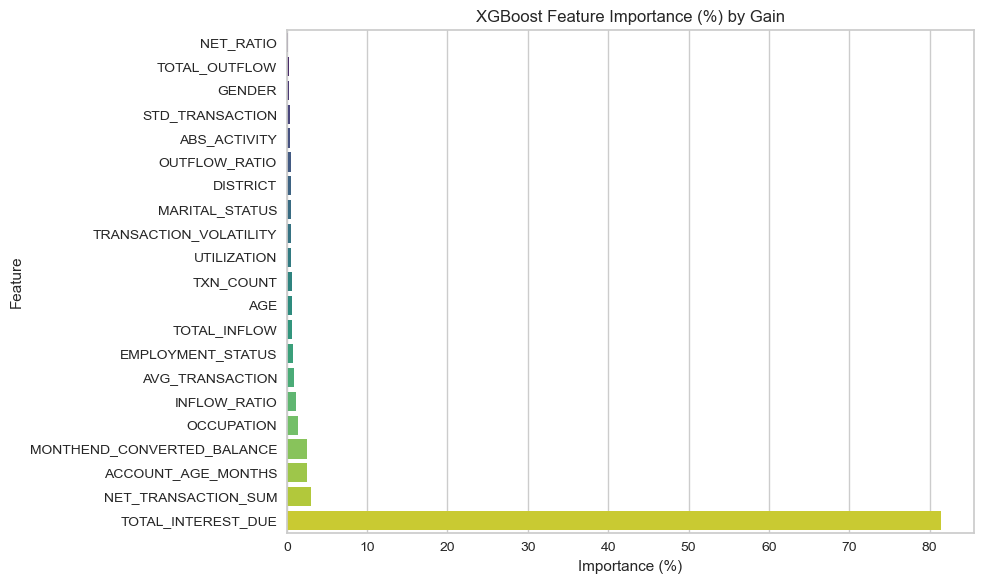

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by Importance %
importance_df = importance_df.sort_values(by='Importance_%', ascending=True)  # ascending for horizontal bar

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance_%', y='Feature', data=importance_df, palette='viridis')
plt.title('XGBoost Feature Importance (%) by Gain')
plt.xlabel('Importance (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [151]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [152]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.9587217043941412

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       689
           1       0.69      0.90      0.78        62

    accuracy                           0.96       751
   macro avg       0.84      0.93      0.88       751
weighted avg       0.97      0.96      0.96       751

ROC-AUC: 0.9872887307458215


Confusion Matrix:
 [[664  25]
 [  6  56]]


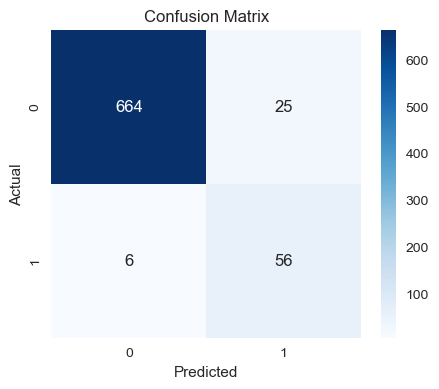

In [153]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Log-transform or cap extreme values

In [154]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier




# Cap at 95th percentile
cap_value = model_data["TOTAL_INTEREST_DUE"].quantile(0.95)
model_data["TOTAL_INTEREST_DUE_CAPPED"] = np.minimum(model_data["TOTAL_INTEREST_DUE"], cap_value)

# Optional: log transform
model_data["TOTAL_INTEREST_DUE_LOG"] = np.log1p(model_data["TOTAL_INTEREST_DUE_CAPPED"])

# Use the transformed column in features
features_transformed = features.copy()
features_transformed = [f if f != "TOTAL_INTEREST_DUE" else "TOTAL_INTEREST_DUE_LOG" for f in features_transformed]


In [155]:
xgb_default_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    reg_alpha=1,       # L1 regularization
    reg_lambda=2,      # L2 regularization
    scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
    random_state=42,
    use_label_encoder=False,
    enable_categorical=True,
    eval_metric='logloss'
)

xgb_default_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [156]:
y_pred = xgb_default_model.predict(X_test)
y_prob = xgb_default_model.predict_proba(X_test)[:,1]

In [157]:
importance = xgb_default_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance': importance.values()
})
importance_df['Importance_%'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Importance_%', ascending=False)
print(importance_df)

                       Feature  Importance  Importance_%
11          TOTAL_INTEREST_DUE   67.553070     74.939695
17                  OCCUPATION    2.865182      3.178477
14          ACCOUNT_AGE_MONTHS    2.294114      2.544965
12  MONTHEND_CONVERTED_BALANCE    2.229900      2.473730
20                    DISTRICT    2.037143      2.259896
7                 INFLOW_RATIO    1.874662      2.079648
0                 TOTAL_INFLOW    1.721538      1.909780
2          NET_TRANSACTION_SUM    1.216992      1.350065
4              AVG_TRANSACTION    0.967830      1.073658
18                      GENDER    0.921477      1.022236
16           EMPLOYMENT_STATUS    0.848215      0.940964
13                 UTILIZATION    0.829908      0.920654
1                TOTAL_OUTFLOW    0.773767      0.858375
19              MARITAL_STATUS    0.761199      0.844433
6                    TXN_COUNT    0.697618      0.773900
3                 ABS_ACTIVITY    0.625393      0.693777
10      TRANSACTION_VOLATILITY 

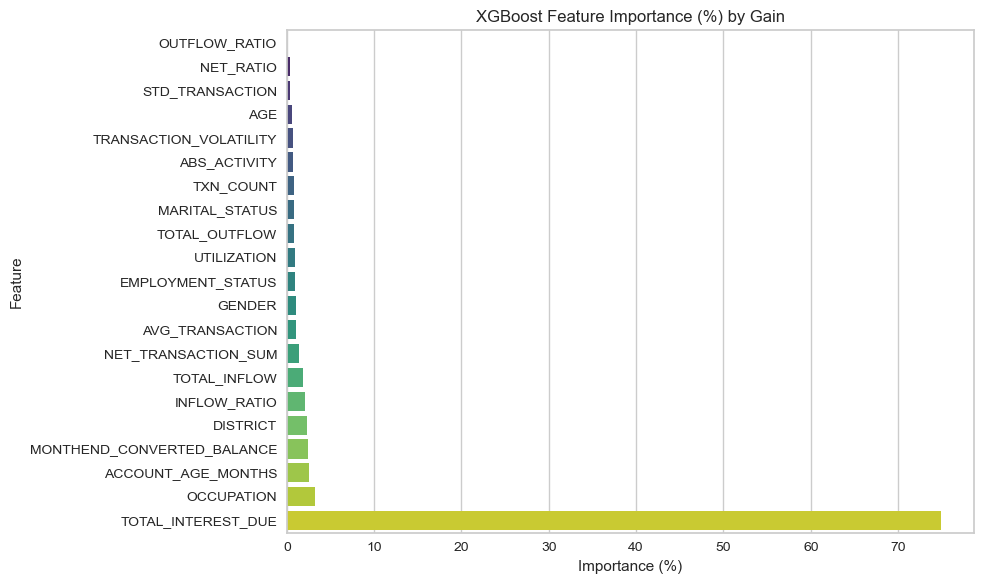

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by Importance for better plotting
importance_df_sorted = importance_df.sort_values(by='Importance_%', ascending=True)  # horizontal bar

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance_%', y='Feature', data=importance_df_sorted, palette='viridis')
plt.title('XGBoost Feature Importance (%) by Gain')
plt.xlabel('Importance (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [159]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.96271637816245

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       689
           1       0.74      0.85      0.79        62

    accuracy                           0.96       751
   macro avg       0.86      0.91      0.89       751
weighted avg       0.97      0.96      0.96       751

ROC-AUC: 0.9874291867596797


Confusion Matrix:
 [[670  19]
 [  9  53]]


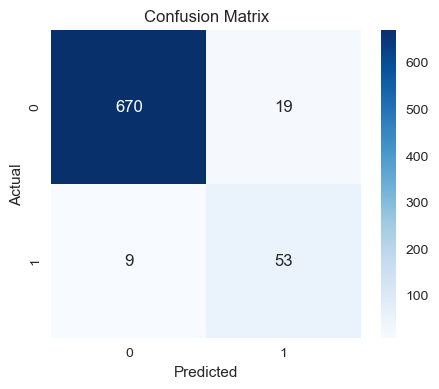

In [160]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Optional: visualize as heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# trying monotone_constraints

In [161]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

# Create monotone constraints: +1 = increasing, 0 = unconstrained
# Ensure the length matches X_train columns
# Example: only TOTAL_INTEREST_DUE is increasing, rest are unconstrained
monotone_constraints = []
for f in X_train.columns:
    if f == "TOTAL_INTEREST_DUE":
        monotone_constraints.append(1)
    else:
        monotone_constraints.append(0)

# Convert to tuple (XGBoost requires tuple)
monotone_constraints = tuple(monotone_constraints)

In [162]:
# Example: constrain only TOTAL_INTEREST_DUE to increase
monotone_constraints = tuple(1 if f == "TOTAL_INTEREST_DUE" else 0 for f in X_train.columns)

# Create model
xgb_monotone_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    enable_categorical=True,
    monotone_constraints=monotone_constraints  # must be a tuple
)

# Train
xgb_monotone_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
                                    0, 0, 0, 0, 0, 0, 0, 0, 0),
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [163]:


# Predict and evaluate
y_pred = xgb_monotone_model.predict(X_test)
y_proba = xgb_monotone_model.predict_proba(X_test)[:, 1]

In [164]:
# Feature importance by gain
importance = xgb_monotone_model.get_booster().get_score(importance_type='gain')
importance_df_m = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance': importance.values()
})
importance_df_m['Importance_%'] = 100 * importance_df_m['Importance'] / importance_df_m['Importance'].sum()
importance_df_m = importance_df_m.sort_values(by='Importance_%', ascending=False)
print(importance_df_m)

                       Feature  Importance  Importance_%
11          TOTAL_INTEREST_DUE   69.773483     72.991476
12  MONTHEND_CONVERTED_BALANCE    3.143506      3.288486
14          ACCOUNT_AGE_MONTHS    3.105377      3.248599
7                 INFLOW_RATIO    2.680168      2.803779
17                  OCCUPATION    2.277441      2.382478
20                    DISTRICT    2.049153      2.143661
18                      GENDER    1.659722      1.736269
4              AVG_TRANSACTION    1.619721      1.694423
6                    TXN_COUNT    1.348780      1.410986
0                 TOTAL_INFLOW    1.275640      1.334473
13                 UTILIZATION    0.941829      0.985267
10      TRANSACTION_VOLATILITY    0.857062      0.896590
1                TOTAL_OUTFLOW    0.828315      0.866517
15                         AGE    0.819981      0.857799
2          NET_TRANSACTION_SUM    0.750441      0.785052
16           EMPLOYMENT_STATUS    0.630411      0.659486
5              STD_TRANSACTION 

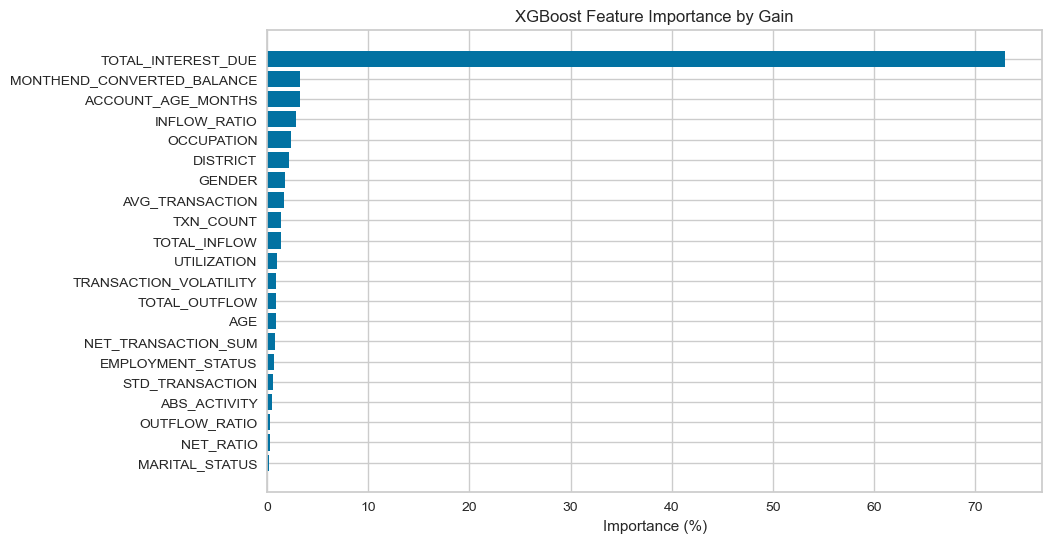

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importance_df_m['Feature'], importance_df_m['Importance_%'])
plt.xlabel("Importance (%)")
plt.title("XGBoost Feature Importance by Gain")
plt.gca().invert_yaxis()
plt.show()

In [166]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.96271637816245

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       689
           1       0.72      0.89      0.80        62

    accuracy                           0.96       751
   macro avg       0.86      0.93      0.89       751
weighted avg       0.97      0.96      0.96       751

ROC-AUC: 0.9885528348705462


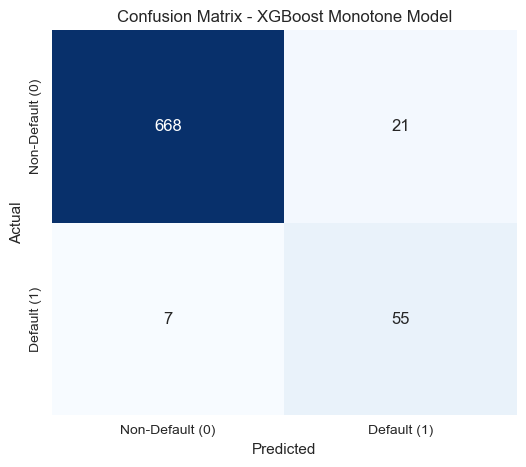

In [167]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Non-Default (0)", "Default (1)"],
            yticklabels=["Non-Default (0)", "Default (1)"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix - XGBoost Monotone Model")
plt.show()

# Chosing the monotone_constraints
With Monotone Constraint

If we add a monotone constraint on TOTAL_INTEREST_DUE:

CatBoost/XGBoost is told: “predicted risk should increase or stay the same as TOTAL_INTEREST_DUE increases.”

After training, the predictions might look like:

Customer	TOTAL_INTEREST_DUE	Predicted Default Probability (with constraint)
A	500	0.10
B	2000	0.15
C	5000	0.25

✅ Now the predictions align with business intuition: higher debt → higher default risk.
Why it matters in credit scoring

Regulatory compliance – Credit models are often audited. Monotone constraints make the model more interpretable.

Trust for business users – Relationship managers or credit officers can trust the model outputs.

Reduces nonsensical predictions – Without constraints, extreme or sparse values could create anomalies where a customer with very high debt gets a lower predicted risk.

## Chking the model data table count and the eligible data count

In [168]:
# Count of rows (customers) in model_data
num_model_data = model_data.shape[0]

# Count of rows (customers) in eligible_cus_df
num_eligible = eligible_cus_df.shape[0]

print(f"Number of customers in model_data: {num_model_data}")
print(f"Number of eligible customers: {num_eligible}")

Number of customers in model_data: 2502
Number of eligible customers: 2502


# can i train on the full data set 

In [169]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Copy features
X_cv = X.copy()

# Encode categorical columns as numeric codes
for col in categorical_cols:
    X_cv[col] = X_cv[col].cat.codes

# Define model with regularization
xgb_reg_cv = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    scale_pos_weight=(len(y)-sum(y))/sum(y),
    reg_alpha=5,
    reg_lambda=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 5-fold cross-validation with ROC-AUC
cv_scores = cross_val_score(xgb_reg_cv, X_cv, y, cv=5, scoring='roc_auc')
print("Cross-validation AUC scores:", cv_scores)
print("Mean CV AUC:", np.mean(cv_scores))

Cross-validation AUC scores: [0.96130304 0.97937434 0.99117913 0.9912854  0.98634359]
Mean CV AUC: 0.9818970992819578


In [170]:
# Encode categorical columns for full model
X_full = X.copy()
for col in categorical_cols:
    X_full[col] = X_full[col].cat.codes

# Train final model on all customers
xgb_reg_full = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    scale_pos_weight=(len(y)-sum(y))/sum(y),
    reg_alpha=5,
    reg_lambda=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_reg_full.fit(X_full, y)

# Predict credit scores (probability of default)
model_data['default_probability'] = xgb_reg_full.predict_proba(X_full)[:, 1]

In [171]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

# Feature importance
importance = xgb_reg_full.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance': importance.values()
})
importance_df['Importance_%'] = 100 * importance_df['Importance'] / importance_df['Importance'].sum()
importance_df = importance_df.sort_values(by='Importance_%', ascending=False)
print(importance_df)

# Evaluate model on full data (for reference)
y_pred_full = xgb_reg_full.predict(X_full)
print(classification_report(y, y_pred_full))
print("ROC-AUC:", roc_auc_score(y, model_data['default_probability']))

                       Feature  Importance  Importance_%
10          TOTAL_INTEREST_DUE  118.824585     79.414634
11  MONTHEND_CONVERTED_BALANCE    4.385466      2.930961
7                 INFLOW_RATIO    3.464358      2.315352
13          ACCOUNT_AGE_MONTHS    3.307966      2.210830
4              AVG_TRANSACTION    2.456806      1.641970
2          NET_TRANSACTION_SUM    2.432204      1.625527
6                    TXN_COUNT    2.083727      1.392628
12                 UTILIZATION    1.497528      1.000850
3                 ABS_ACTIVITY    1.401763      0.936847
0                 TOTAL_INFLOW    1.295160      0.865601
9       TRANSACTION_VOLATILITY    1.276181      0.852917
5              STD_TRANSACTION    1.152563      0.770298
14                         AGE    0.988797      0.660848
17                      GENDER    0.907726      0.606665
1                TOTAL_OUTFLOW    0.868442      0.580410
18              MARITAL_STATUS    0.756808      0.505802
19                    DISTRICT 

In [172]:
y_proba = xgb_reg_full.predict_proba(X_full)[:,1]
y_pred = xgb_reg_full.predict(X_full)

In [173]:
results = pd.DataFrame({
    'MASKED_ID': model_data['MASKED_ID'],
    'Default_Probability': y_proba,
    'Predicted_Default': y_pred
})

In [174]:

min_score = 300
max_score = 850
results['Internal_Bank_Score'] = max_score - (y_proba * (max_score - min_score))
results['Internal_Bank_Default_Score'] = results['Internal_Bank_Score'].round().astype(int)
results

,MASKED_ID,Default_Probability,Predicted_Default,Internal_Bank_Score,Internal_Bank_Default_Score
0,000454,0.973655,1,314.489685,314
1,000866,0.000646,0,849.644531,850
2,001135,0.001314,0,849.277161,849
3,001538,0.349927,0,657.540222,658
4,001906,0.000519,0,849.714478,850
...,...,...,...,...,...
2497,9998375,0.001271,0,849.300842,849
2498,9998721,0.002231,0,848.772766,849
2499,9999535,0.001777,0,849.022827,849
2500,9999658,0.003640,0,847.997742,848


In [175]:
bins = [300, 550, 650, 750, 850]
labels = ["High Risk","Medium Risk","Low Risk","Very Low Risk"]

results["Score_Band"] = pd.cut(
    results["Internal_Bank_Default_Score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [176]:
final_table = model_data.merge(results, on="MASKED_ID", how="left")

In [177]:
# Total number of rows
total_rows = len(final_table)
print("Total rows in table:", total_rows)

Total rows in table: 2502


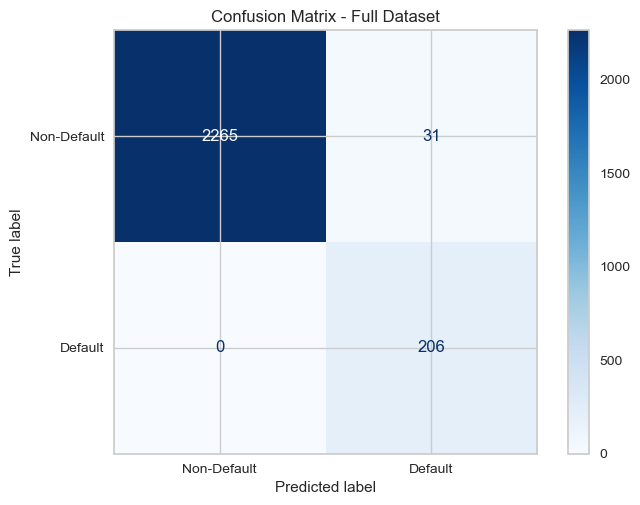

[[2265   31]
 [   0  206]]


In [178]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make sure actual labels exist
y_true = final_table['DEFAULT']          # Actual defaults
y_pred = final_table['Predicted_Default']  # Predicted defaults

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Default", "Default"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Full Dataset")
plt.show()

# Print counts
print(cm)

In [179]:
len(final_table)

2502

In [180]:
score_summary = final_table.groupby("Score_Band").size().reset_index(name="Customer_Count")
print(score_summary)

      Score_Band  Customer_Count
0      High Risk             231
1    Medium Risk              22
2       Low Risk              32
3  Very Low Risk            2217


In [181]:
final_table

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,...,TOTAL_PAID,DEFAULT,TOTAL_INTEREST_DUE_CAPPED,TOTAL_INTEREST_DUE_LOG,default_probability,Default_Probability,Predicted_Default,Internal_Bank_Score,Internal_Bank_Default_Score,Score_Band
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,...,2.243390e+06,1,135138.47,11.814063,0.973655,0.973655,1,314.489685,314,High Risk
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,...,0.000000e+00,0,0.00,0.000000,0.000646,0.000646,0,849.644531,850,Very Low Risk
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.001314,0.001314,0,849.277161,849,Very Low Risk
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,...,3.105992e+05,0,20821.79,9.943803,0.349927,0.349927,0,657.540222,658,Low Risk
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,...,0.000000e+00,0,0.00,0.000000,0.000519,0.000519,0,849.714478,850,Very Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.001271,0.001271,0,849.300842,849,Very Low Risk
2498,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.002231,0.002231,0,848.772766,849,Very Low Risk
2499,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.001777,0.001777,0,849.022827,849,Very Low Risk
2500,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.003640,0.003640,0,847.997742,848,Very Low Risk


# Testing SMOTE since the data is imbalanced

In [182]:
# pip install imbalanced-learn

In [183]:
# from imblearn.over_sampling import SMOTE
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, roc_auc_score
# from sklearn.model_selection import train_test_split

In [184]:
# # Split data (separate variables)
# X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
#     X, y, test_size=0.3, random_state=42
# )

# # Scale numeric columns (separate scaler)
# numeric_cols = X.select_dtypes(include=["int64","float64"]).columns
# scaler_smote = StandardScaler()
# X_train_scaled = X_orig_train.copy()
# X_test_scaled = X_orig_test.copy()


In [185]:
# X_train_scaled[numeric_cols] = scaler_smote.fit_transform(X_train_scaled[numeric_cols])
# X_test_scaled[numeric_cols] = scaler_smote.transform(X_test_scaled[numeric_cols])

# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [186]:
# from sklearn.linear_model import LogisticRegression
# model = LogisticRegression(max_iter=1000)
# model.fit(X_train_res, y_train_res)



In [187]:
# from sklearn.metrics import classification_report, roc_auc_score
# y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)[:,1]

# print(classification_report(y_test, y_pred))
# print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [188]:
# min_score = 250
# max_score = 900

# model_data["CREDIT_SCORE"] = (
#     (1 - model.predict_proba(scaler.transform(X))[:,1]) * (max_score - min_score) + min_score
# ).round(0)

# Start - Defining clusters

In [189]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

features = [
    'AGE',
    'Monthly_Avg_Balance',
    'Avg_Monthly_Credit',
    'Number_of_Active_Accounts'
]

X = eligible_cus_df[features]

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Model 1 -  K-Means

In [190]:
# from sklearn.cluster import KMeans

# kmeans = KMeans(n_clusters=4, random_state=42)
# labels_km = kmeans.fit_predict(X)


In [191]:
eligible_cus_df[features].isna().sum()

AGE                           0
Monthly_Avg_Balance           1
Avg_Monthly_Credit           51
Number_of_Active_Accounts     0
dtype: int64

In [192]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [193]:
features = [
    'AGE',
    'Monthly_Avg_Balance',
    'Avg_Monthly_Credit',
    'Number_of_Active_Accounts'
]

X = eligible_cus_df[features]

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(random_state=42))
])


# Imputation step
# → fills missing values (median)

# Scaling step
# → standardizes features (required for distance-based clustering)

# KMeans clustering
# → the actual clustering algorithm

In [194]:
from sklearn.metrics import silhouette_score

best_score = -1  # initialize BEFORE the loop
best_k = None

for k in range(2, 8):
    pipe.set_params(kmeans__n_clusters=k)
    labels = pipe.fit_predict(X)

    X_transformed = pipe[:-1].transform(X)
    score = silhouette_score(X_transformed, labels)

    print(f'k={k}, silhouette score={score:.3f}')

    # Keep track of the best score
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nOptimal number of clusters: {best_k} with silhouette score: {best_score:.3f}")

k=2, silhouette score=0.678
k=3, silhouette score=0.411
k=4, silhouette score=0.425
k=5, silhouette score=0.435
k=6, silhouette score=0.364
k=7, silhouette score=0.373

Optimal number of clusters: 2 with silhouette score: 0.678


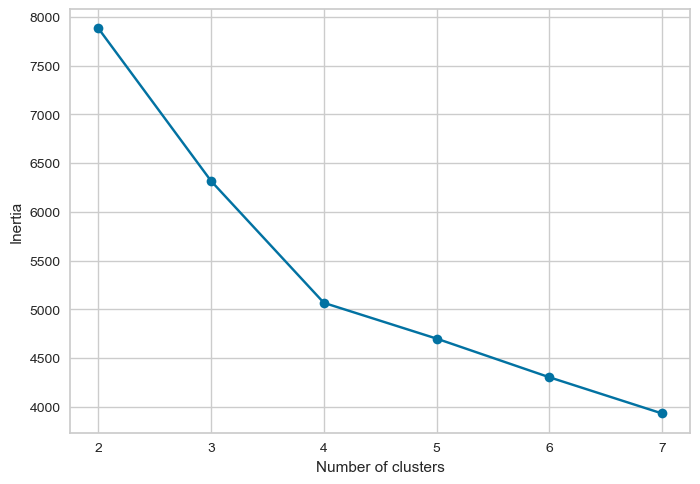

In [195]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


# Model 2 - GMM

In [196]:
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

gmm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('gmm', GaussianMixture(random_state=42))
])


In [197]:
bic_scores = []
aic_scores = []

for k in range(2, 8):
    gmm_pipe.set_params(gmm__n_components=k)
    gmm_pipe.fit(X)

    gmm = gmm_pipe.named_steps['gmm']
    bic_scores.append(gmm.bic(gmm_pipe[:-1].transform(X)))
    aic_scores.append(gmm.aic(gmm_pipe[:-1].transform(X)))

    print(f'k={k}, BIC={bic_scores[-1]:.0f}, AIC={aic_scores[-1]:.0f}')
    
    
# Lower BIC = better

# BIC penalizes too many clusters

# Usually smoother and safer than AIC

k=2, BIC=2341, AIC=2172
k=3, BIC=-3308, AIC=-3564
k=4, BIC=-15106, AIC=-15450
k=5, BIC=-15595, AIC=-16026
k=6, BIC=-16212, AIC=-16731
k=7, BIC=-16455, AIC=-17060


In [198]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    gmm_pipe.set_params(gmm__n_components=k)
    labels = gmm_pipe.fit_predict(X)

    X_transformed = gmm_pipe[:-1].transform(X)
    score = silhouette_score(X_transformed, labels)

    print(f'k={k}, silhouette={score:.3f}')

k=2, silhouette=0.212
k=3, silhouette=0.002
k=4, silhouette=-0.002
k=5, silhouette=0.001
k=6, silhouette=-0.001
k=7, silhouette=-0.009


# Model 3 - Hierarchical Clustering

In [199]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Preprocess (same logic, no leakage)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)


In [200]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'  # best for numeric risk data
    )
    labels = agg.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    print(f'k={k}, silhouette={score:.3f}')


k=2, silhouette=0.618
k=3, silhouette=0.595
k=4, silhouette=0.301
k=5, silhouette=0.315
k=6, silhouette=0.304
k=7, silhouette=0.310


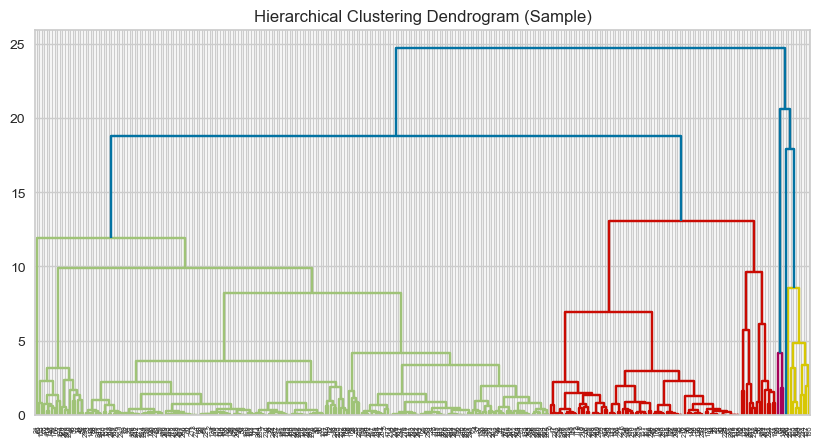

In [201]:
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

sample_idx = np.random.choice(len(X_scaled), size=300, replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram (Sample)')
plt.show()


# Model 6 K-Prototypes

In [202]:
!pip install kmodes

Defaulting to user installation because normal site-packages is not writeable


In [203]:
import pandas as pd
from kmodes.kprototypes import KPrototypes

In [204]:
# Filter eligible customers
eligible_df_k = final_table[final_table['Eligibility_Flag'].str.upper() == 'ELIGIBLE'].copy()

In [205]:
# Total number of rows
total_rows = len(eligible_df_k)
print("Total rows in table:", total_rows)

Total rows in table: 2493


In [206]:
eligible_df_k

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,...,TOTAL_PAID,DEFAULT,TOTAL_INTEREST_DUE_CAPPED,TOTAL_INTEREST_DUE_LOG,default_probability,Default_Probability,Predicted_Default,Internal_Bank_Score,Internal_Bank_Default_Score,Score_Band
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,...,2.243390e+06,1,135138.47,11.814063,0.973655,0.973655,1,314.489685,314,High Risk
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,...,0.000000e+00,0,0.00,0.000000,0.000646,0.000646,0,849.644531,850,Very Low Risk
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.001314,0.001314,0,849.277161,849,Very Low Risk
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,...,3.105992e+05,0,20821.79,9.943803,0.349927,0.349927,0,657.540222,658,Low Risk
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,...,0.000000e+00,0,0.00,0.000000,0.000519,0.000519,0,849.714478,850,Very Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.001271,0.001271,0,849.300842,849,Very Low Risk
2498,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.002231,0.002231,0,848.772766,849,Very Low Risk
2499,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.001777,0.001777,0,849.022827,849,Very Low Risk
2500,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.003640,0.003640,0,847.997742,848,Very Low Risk


In [207]:
# Define features
numeric_features = ['Monthly_Avg_Balance', 'Avg_Monthly_Credit','AGE','Internal_Bank_Default_Score']
categorical_features = ['OCCUPATION','CUSTOMER_RISK_NAME','GENDER', 'EMPLOYMENT_STATUS', 'MARITAL_STATUS','TARGET_DESC']

In [208]:
# Fill missing values
eligible_df_k[numeric_features] = eligible_df_k[numeric_features].fillna(0)
for col in categorical_features:
    eligible_df_k[col] = eligible_df_k[col].astype(str).fillna('Unknown')

In [209]:
cluster_data = eligible_df_k[numeric_features + categorical_features].copy()
cat_idx = [cluster_data.columns.get_loc(col) for col in categorical_features]

In [210]:
cluster_data

,Monthly_Avg_Balance,Avg_Monthly_Credit,AGE,Internal_Bank_Default_Score,OCCUPATION,CUSTOMER_RISK_NAME,GENDER,EMPLOYMENT_STATUS,MARITAL_STATUS,TARGET_DESC
0,240032.314495,594627.180067,36,314,Entrepreneur / Business Owners,LOW,FEMALE,UNEMPLOYED,MARRIED,Signature
1,1288.532501,1288.532501,27,850,Garment & Related Trade Workers,LOW,FEMALE,EMPLOYED,SINGLE,Premier
2,0.000000,0.000000,41,849,Private Sector Non-Executives,LOW,FEMALE,EMPLOYED,Unknown,Essential
3,-42844.881154,406128.730574,25,658,Finance Professionals,LOW,FEMALE,EMPLOYED,Unknown,Essential
4,1377.552490,1377.552490,61,850,Entrepreneur / Business Owners,LOW,FEMALE,UNEMPLOYED,MARRIED,Signature
...,...,...,...,...,...,...,...,...,...,...
2497,5273.733337,84100.000000,39,849,Private Sector Executives,LOW,FEMALE,EMPLOYED,SINGLE,Essential
2498,26121.969971,418690.281250,34,849,Entrepreneur / Business Owners,MEDIUM,MALE,BUSINESS,SINGLE,Essential
2499,243207.672119,626505.000000,45,849,Entrepreneur / Business Owners,LOW,MALE,SELF-EMPLOYED,MARRIED,Essential
2500,64698.908854,32400.000000,29,848,Entrepreneur / Business Owners,LOW,FEMALE,SELF-EMPLOYED,MARRIED,Essential


In [211]:
# import matplotlib.pyplot as plt

# cost = []
# K = range(2, 10) 
#  # test 2 to 9 clusters

# for k in K:
#     kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42)
#     kproto.fit_predict(cluster_data, categorical=cat_idx)
#     cost.append(kproto.cost_)




In [212]:
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt

# Prepare numeric + encoded categorical data
cluster_numeric = cluster_data.copy()
for col in categorical_features:
    cluster_numeric[col] = cluster_numeric[col].astype('category').cat.codes



In [213]:
# Define range of clusters to test
K = range(2, 9)

# Initialize lists to store metrics
cost = []
sil_scores = []
ch_scores = []

# Loop once per k and compute all metrics
for k in K:
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42)
    labels = kproto.fit_predict(cluster_data.values, categorical=cat_idx)

    cost.append(kproto.cost_)
    sil_scores.append(silhouette_score(cluster_numeric, labels, metric='euclidean'))
    ch_scores.append(calinski_harabasz_score(cluster_numeric, labels))
    
  

In [214]:
print("K:", K)
print("Length of K:", len(K))
print("Cost:", cost)
print("Length of cost:", len(cost))


K: range(2, 9)
Length of K: 7
Cost: [1.0673512856458268e+16, 5660337336027118.0, 4250347349907371.0, 3720855235616322.0, 3439477936668321.0, 3238461875440980.5, 3086505710663976.0]
Length of cost: 7


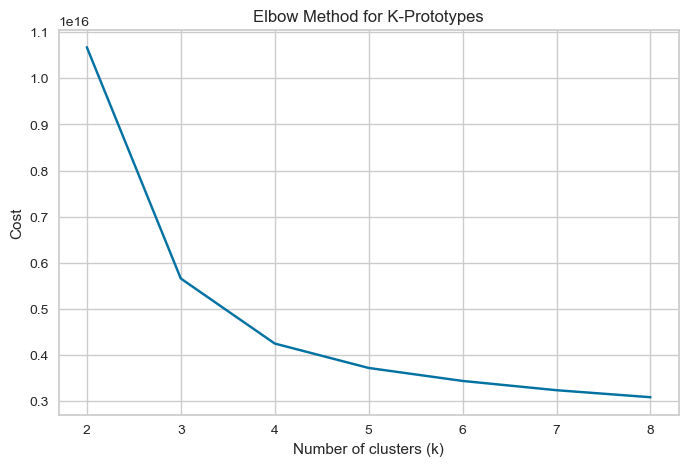

In [215]:
# Plot Elbow (Cost)
plt.figure(figsize=(8,5))
plt.plot(K, cost, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Cost')
plt.title('Elbow Method for K-Prototypes')
plt.show()

In [216]:
!pip install kneed


from kneed import KneeLocator
import matplotlib.pyplot as plt

knee = KneeLocator(K, cost, curve='convex', direction='decreasing')
optimal_k = knee.knee

print("Optimal number of clusters (Elbow Method):", optimal_k)

Defaulting to user installation because normal site-packages is not writeable
Optimal number of clusters (Elbow Method): 4


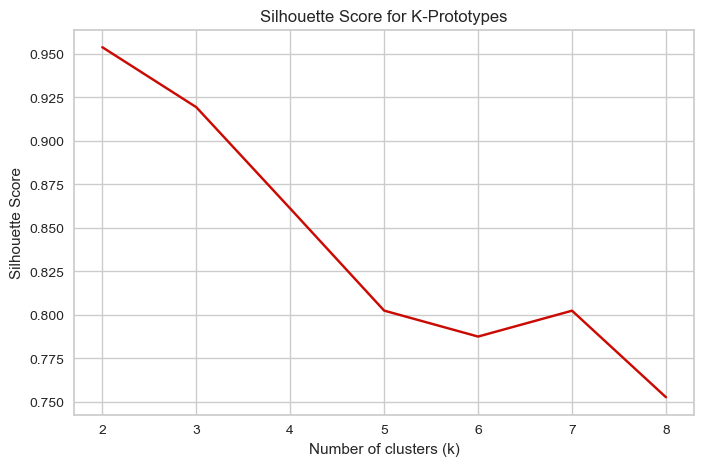

In [217]:
# Plot Silhouette Score
plt.figure(figsize=(8,5))
plt.plot(K, sil_scores, 'rx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-Prototypes')
plt.show()

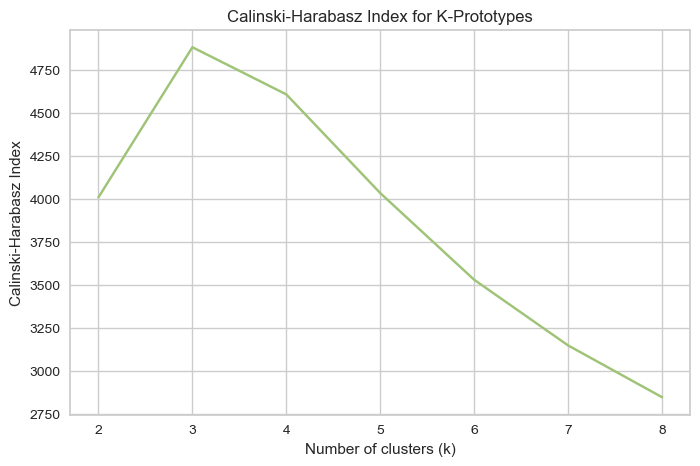

In [218]:
# Plot Calinski-Harabasz Index
plt.figure(figsize=(8,5))
plt.plot(K, ch_scores, 'gx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index for K-Prototypes')
plt.show()


In [219]:
# Print all metrics per k
for i, k_val in enumerate(K):
    print(f"k={k_val} -> Cost: {cost[i]:.2f}, Silhouette: {sil_scores[i]:.4f}, CH: {ch_scores[i]:.2f}")

k=2 -> Cost: 10673512856458268.00, Silhouette: 0.9538, CH: 4009.70
k=3 -> Cost: 5660337336027118.00, Silhouette: 0.9193, CH: 4881.62
k=4 -> Cost: 4250347349907371.00, Silhouette: 0.8611, CH: 4607.51
k=5 -> Cost: 3720855235616322.00, Silhouette: 0.8025, CH: 4034.31
k=6 -> Cost: 3439477936668321.00, Silhouette: 0.7876, CH: 3530.77
k=7 -> Cost: 3238461875440980.50, Silhouette: 0.8024, CH: 3149.40
k=8 -> Cost: 3086505710663976.00, Silhouette: 0.7527, CH: 2848.73


In [220]:
# Copy cluster_data so we don't modify the original
cluster_numeric = cluster_data.copy()

for col in categorical_features:
    cluster_numeric[col] = cluster_numeric[col].astype('category').cat.codes


# Model 7 - Gower

In [221]:
!pip install gower


Defaulting to user installation because normal site-packages is not writeable


In [222]:
import pandas as pd
import numpy as np

# Select features
numeric_features = [
    'AGE',
    'Monthly_Avg_Balance',
    'Avg_Monthly_Credit','Internal_Bank_Default_Score'
]


categorical_features = [
    'GENDER',
    'EMPLOYMENT_STATUS',
    'MARITAL_STATUS',
    'Employment_Segment','TARGET_DESC','CUSTOMER_RISK_NAME'
]

gower_df = final_table[
    final_table['Eligibility_Flag'].str.upper() == 'ELIGIBLE'
][numeric_features + categorical_features].copy()

for col in categorical_features:
    gower_df[col] = gower_df[col].astype('category')  # ensure categorical
    if 'Unknown' not in gower_df[col].cat.categories:
        gower_df[col] = gower_df[col].cat.add_categories('Unknown')
    gower_df[col] = gower_df[col].fillna('Unknown')


In [223]:
# Handle missing values for numeric columns
gower_df[numeric_features] = gower_df[numeric_features].fillna(gower_df[numeric_features].median())

# Convert categorical columns to string and fill missing values
gower_df[categorical_features] = gower_df[categorical_features].astype(str).fillna('Unknown')

# Now compute Gower distance
import gower
gower_dist = gower.gower_matrix(gower_df)

In [224]:
import gower

gower_dist = gower.gower_matrix(gower_df)


In [225]:
from sklearn.cluster import AgglomerativeClustering

n_clusters = 4  

hc = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='precomputed',
    linkage='average'
)

gower_df['Cluster'] = hc.fit_predict(gower_dist)


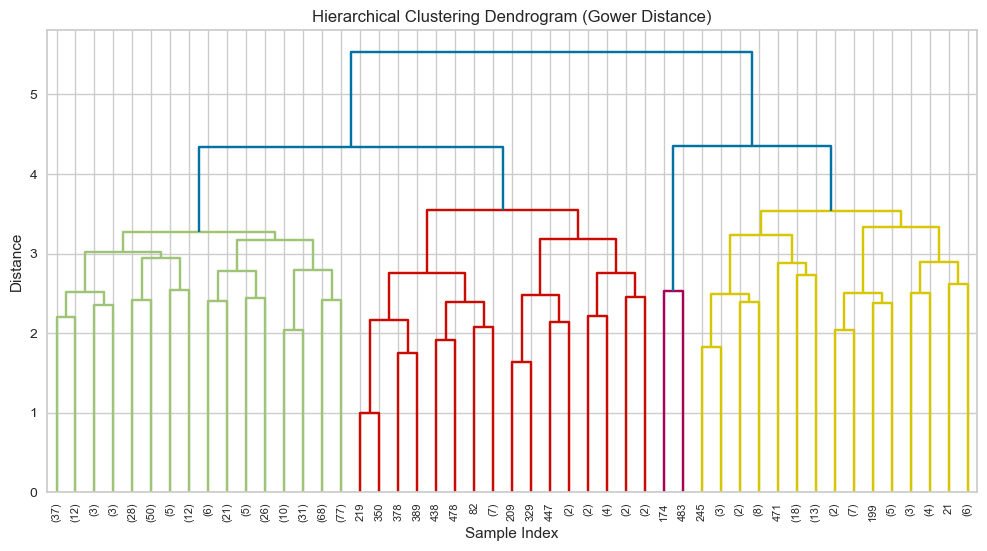

In [226]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

sample = gower_df.sample(n=500, random_state=42)
gower_sample = gower.gower_matrix(sample)

Z = linkage(gower_sample, method='average')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Gower Distance)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()


In [227]:
gower_df.groupby('Cluster')[numeric_features].mean()


,AGE,Monthly_Avg_Balance,Avg_Monthly_Credit,Internal_Bank_Default_Score
Cluster,,,,
0,36.980392,59408.176029,734467.091279,790.266858
1,50.454545,-781209.628729,184569.465398,498.818182
2,67.340102,378082.963544,554686.243751,831.700508
3,33.082474,130847.789014,238465.794656,831.154639


In [228]:
for col in categorical_features:
    print(f"\n{col}")
    print(pd.crosstab(gower_df['Cluster'], gower_df[col], normalize='index'))



GENDER
GENDER     FEMALE      MALE
Cluster                    
0        0.350550  0.649450
1        0.363636  0.636364
2        0.421320  0.578680
3        0.711340  0.288660

EMPLOYMENT_STATUS
EMPLOYMENT_STATUS  BUSINESS  EMPLOYED  FREELANCE   RETIRED  SELF-EMPLOYED  \
Cluster                                                                     
0                  0.107126  0.493066   0.000000  0.000000       0.399809   
1                  0.000000  0.000000   0.090909  0.909091       0.000000   
2                  0.101523  0.233503   0.000000  0.137056       0.375635   
3                  0.000000  0.000000   0.030928  0.005155       0.000000   

EMPLOYMENT_STATUS   STUDENT  UNEMPLOYED   Unknown  
Cluster                                            
0                  0.000000    0.000000  0.000000  
1                  0.000000    0.000000  0.000000  
2                  0.000000    0.147208  0.005076  
3                  0.360825    0.551546  0.051546  

MARITAL_STATUS
MARITAL_STATUS

# comparing each model

In [229]:
from sklearn.preprocessing import StandardScaler

# One-hot encode categorical features
encoded_df = pd.get_dummies(cluster_data, drop_first=True)

# Scale numeric features
scaler = StandardScaler()
encoded_df[numeric_features] = scaler.fit_transform(encoded_df[numeric_features])

# Convert to numpy array for metrics
X_encoded = encoded_df.values

print("X_encoded rows:", len(X_encoded))


X_encoded rows: 2493


In [230]:
k = 4

# K-Prototypes
kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42)
kproto_labels = kproto.fit_predict(cluster_data.values, categorical=cat_idx)
sil_kproto = silhouette_score(X_encoded, kproto_labels, metric='euclidean')

# Gower
hc = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
gower_labels = hc.fit_predict(gower_dist)
sil_gower = silhouette_score(gower_dist, gower_labels, metric='precomputed')

print("Silhouette K-Prototypes:", sil_kproto)
print("Silhouette Gower:", sil_gower)


Silhouette K-Prototypes: 0.22733703719252804
Silhouette Gower: 0.27641663


In [231]:
# CH Scores
from sklearn.metrics import calinski_harabasz_score
ch_kproto = calinski_harabasz_score(X_encoded, kproto_labels)
ch_gower = calinski_harabasz_score(X_encoded, gower_labels)

print("Calinski-Harabasz K-Prototypes:", ch_kproto)
print("Calinski-Harabasz Gower:", ch_gower)


Calinski-Harabasz K-Prototypes: 148.07094033306512
Calinski-Harabasz Gower: 78.01585882568823


In [232]:
from sklearn.metrics import davies_bouldin_score

# Davies–Bouldin for K-Prototypes
db_kproto = davies_bouldin_score(X_encoded, kproto_labels)
print("Davies–Bouldin Index (K-Prototypes):", db_kproto)

# Davies–Bouldin for Gower clusters
db_gower = davies_bouldin_score(X_encoded, gower_labels)
print("Davies–Bouldin Index (Gower + Agglomerative):", db_gower)


Davies–Bouldin Index (K-Prototypes): 2.1485050334336684
Davies–Bouldin Index (Gower + Agglomerative): 2.4601478500921354


In [233]:
from sklearn.metrics import adjusted_rand_score

# Assuming you already have:
# kproto_labels -> cluster labels from K-Prototypes
# gower_labels  -> cluster labels from Gower + Agglomerative

# Compute ARI
ari_score = adjusted_rand_score(kproto_labels, gower_labels)

print("Adjusted Rand Index (K-Prototypes vs Gower):", ari_score)


Adjusted Rand Index (K-Prototypes vs Gower): -0.01994524947139296


# Chosing K prototype

In [234]:
from kmodes.kprototypes import KPrototypes
import pandas as pd

# Use a separate copy for final clustering
eligible_final = final_table.copy()

In [235]:
eligible_final

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,...,TOTAL_PAID,DEFAULT,TOTAL_INTEREST_DUE_CAPPED,TOTAL_INTEREST_DUE_LOG,default_probability,Default_Probability,Predicted_Default,Internal_Bank_Score,Internal_Bank_Default_Score,Score_Band
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,...,2.243390e+06,1,135138.47,11.814063,0.973655,0.973655,1,314.489685,314,High Risk
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,...,0.000000e+00,0,0.00,0.000000,0.000646,0.000646,0,849.644531,850,Very Low Risk
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.001314,0.001314,0,849.277161,849,Very Low Risk
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,...,3.105992e+05,0,20821.79,9.943803,0.349927,0.349927,0,657.540222,658,Low Risk
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,...,0.000000e+00,0,0.00,0.000000,0.000519,0.000519,0,849.714478,850,Very Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.001271,0.001271,0,849.300842,849,Very Low Risk
2498,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.002231,0.002231,0,848.772766,849,Very Low Risk
2499,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.001777,0.001777,0,849.022827,849,Very Low Risk
2500,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,...,0.000000e+00,0,0.00,0.000000,0.003640,0.003640,0,847.997742,848,Very Low Risk


In [236]:
# Define features
numeric_feats_final = ['Monthly_Avg_Balance', 'Avg_Monthly_Credit','AGE']
categorical_feats_final = ['OCCUPATION','CUSTOMER_RISK_NAME','GENDER', 
                           'EMPLOYMENT_STATUS', 'MARITAL_STATUS','TARGET_DESC','Score_Band']

In [237]:
# Fill missing values
eligible_final[numeric_feats_final] = eligible_final[numeric_feats_final].fillna(0)
for col in categorical_feats_final:
    eligible_final[col] = eligible_final[col].astype(str).fillna('Unknown')

In [238]:
# Prepare cluster data
cluster_data_final = eligible_final[numeric_feats_final + categorical_feats_final].copy()
# Weight Internal_Bank_Default_Score higher
weight_factor = 5  # you can tune this
cluster_data_final['Internal_Bank_Default_Score'] = eligible_final['Internal_Bank_Default_Score'] * weight_factor

In [239]:
eligible_final[categorical_feats_final] = eligible_final[categorical_feats_final].fillna('Unknown').astype(str)

In [240]:

cat_idx_final = [cluster_data_final.columns.get_loc(col) for col in categorical_feats_final]


In [241]:
# Fit K-Prototypes with k = 4
kproto_final = KPrototypes(n_clusters=4, init='Cao', random_state=42)
cluster_labels_final = kproto_final.fit_predict(cluster_data_final.values, categorical=cat_idx_final)

In [242]:
# Assign cluster labels to dataframe
eligible_final['Cluster_KProto'] = cluster_labels_final

In [243]:
eligible_final

,MASKED_ID,NAME_MASKED_ID,AGE,GENDER,CUSTOMER_RISK,CUSTOMER_RISK_NAME,OCCUPATION,DISTRICT,TARGET_CODE,TARGET_DESC,...,DEFAULT,TOTAL_INTEREST_DUE_CAPPED,TOTAL_INTEREST_DUE_LOG,default_probability,Default_Probability,Predicted_Default,Internal_Bank_Score,Internal_Bank_Default_Score,Score_Band,Cluster_KProto
0,000454,CUSTOMER_356,36,FEMALE,1.0,LOW,Entrepreneur / Business Owners,ANURADHAPURA,948,Signature,...,1,135138.47,11.814063,0.973655,0.973655,1,314.489685,314,High Risk,0
1,000866,CUSTOMER_410,27,FEMALE,1.0,LOW,Garment & Related Trade Workers,ANURADHAPURA,908,Premier,...,0,0.00,0.000000,0.000646,0.000646,0,849.644531,850,Very Low Risk,0
2,001135,CUSTOMER_455,41,FEMALE,1.0,LOW,Private Sector Non-Executives,HAMBANTOTA,988,Essential,...,0,0.00,0.000000,0.001314,0.001314,0,849.277161,849,Very Low Risk,0
3,001538,CUSTOMER_899,25,FEMALE,1.0,LOW,Finance Professionals,GALLE,988,Essential,...,0,20821.79,9.943803,0.349927,0.349927,0,657.540222,658,Low Risk,0
4,001906,CUSTOMER_2307,61,FEMALE,1.0,LOW,Entrepreneur / Business Owners,COLOMBO,948,Signature,...,0,0.00,0.000000,0.000519,0.000519,0,849.714478,850,Very Low Risk,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2497,9998375,CUSTOMER_969,39,FEMALE,1.0,LOW,Private Sector Executives,BADULLA,988,Essential,...,0,0.00,0.000000,0.001271,0.001271,0,849.300842,849,Very Low Risk,0
2498,9998721,CUSTOMER_833,34,MALE,2.0,MEDIUM,Entrepreneur / Business Owners,COLOMBO,988,Essential,...,0,0.00,0.000000,0.002231,0.002231,0,848.772766,849,Very Low Risk,0
2499,9999535,CUSTOMER_1426,45,MALE,1.0,LOW,Entrepreneur / Business Owners,MATALE,988,Essential,...,0,0.00,0.000000,0.001777,0.001777,0,849.022827,849,Very Low Risk,0
2500,9999658,CUSTOMER_2065,29,FEMALE,1.0,LOW,Entrepreneur / Business Owners,GAMPAHA,988,Essential,...,0,0.00,0.000000,0.003640,0.003640,0,847.997742,848,Very Low Risk,0


In [244]:
# # Encode categorical columns as numeric (optional, for metrics)
# cluster_numeric_final = cluster_data_final.copy()
# for col in categorical_feats_final:
#     cluster_numeric_final[col] = cluster_numeric_final[col].astype('category').cat.codes


In [245]:
# Show cluster sizes
cluster_sizes_final = eligible_final['Cluster_KProto'].value_counts().sort_index()
print("Cluster sizes (k=4):")
print(cluster_sizes_final)

Cluster sizes (k=4):
0    2353
1      26
2      10
3     113
Name: Cluster_KProto, dtype: int64


In [246]:
cluster_summary_list = []

for cluster in eligible_final['Cluster_KProto'].unique():
    cluster_data = eligible_final[eligible_final['Cluster_KProto'] == cluster]
    
    summary = {}
    summary['Cluster'] = cluster
    
    # Numeric features: mean
    for col in numeric_feats_final:
        summary[col] = round(cluster_data[col].mean(), 2)
    
    # Categorical features: top category + percentage
    for col in categorical_feats_final:
        top_cat = cluster_data[col].value_counts(normalize=True).idxmax()
        top_pct = round(cluster_data[col].value_counts(normalize=True).max() * 100, 1)
        summary[col] = f"{top_cat} ({top_pct}%)"
    
    cluster_summary_list.append(summary)

# Convert to DataFrame
cluster_summary_df = pd.DataFrame(cluster_summary_list)




In [247]:
# Show table
cluster_summary_df

,Cluster,Monthly_Avg_Balance,Avg_Monthly_Credit,AGE,OCCUPATION,CUSTOMER_RISK_NAME,GENDER,EMPLOYMENT_STATUS,MARITAL_STATUS,TARGET_DESC,Score_Band
0,0,37746.89,172071.14,38.86,Entrepreneur / Business Owners (50.8%),LOW (81.9%),MALE (60.1%),EMPLOYED (43.4%),MARRIED (41.6%),Essential (69.1%),Very Low Risk (89.4%)
1,3,684142.22,4435669.81,43.35,Entrepreneur / Business Owners (51.3%),LOW (65.5%),MALE (83.2%),EMPLOYED (39.8%),MARRIED (54.0%),Essential (54.9%),Very Low Risk (77.0%)
2,1,1052967.98,15230429.29,45.04,Entrepreneur / Business Owners (61.5%),LOW (61.5%),MALE (88.5%),BUSINESS (46.2%),MARRIED (57.7%),Summit (50.0%),Very Low Risk (73.1%)
3,2,2199234.50,40694904.76,38.60,Entrepreneur / Business Owners (40.0%),MEDIUM (60.0%),MALE (80.0%),EMPLOYED (50.0%),SINGLE (40.0%),Summit (50.0%),Very Low Risk (80.0%)


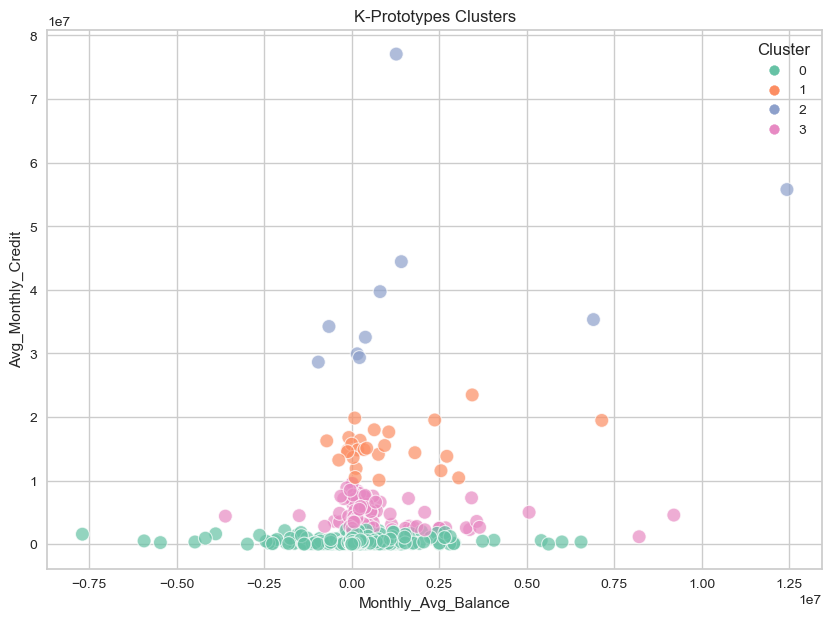

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose two numeric features for the scatter plot
x_feature = 'Monthly_Avg_Balance'
y_feature = 'Avg_Monthly_Credit'

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=eligible_final,
    x=x_feature,
    y=y_feature,
    hue='Cluster_KProto',        # color by cluster
    palette='Set2',              # different colors
    s=100,                       # marker size
    alpha=0.7                     # transparency
)

plt.title('K-Prototypes Clusters')
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


<AxesSubplot:xlabel='Internal_Bank_Default_Score', ylabel='Density'>

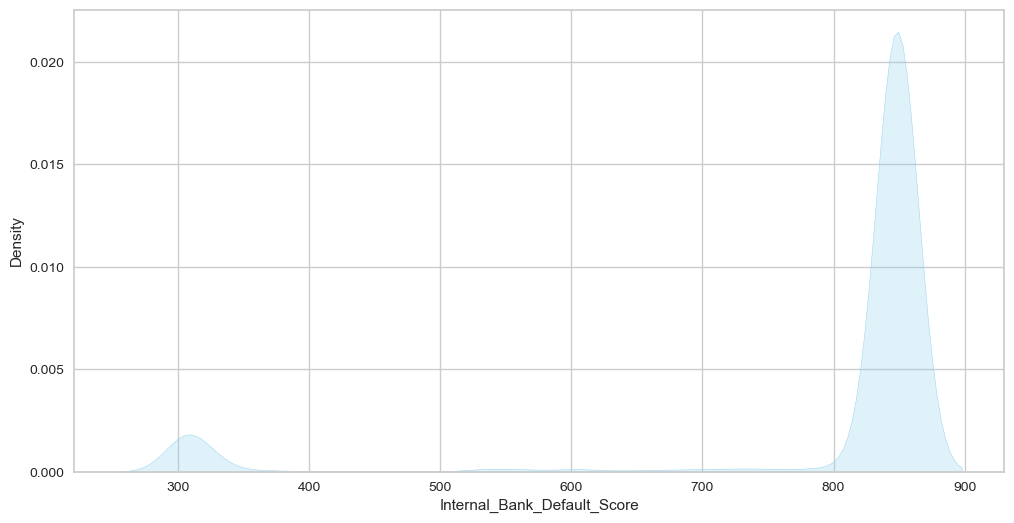

In [249]:
# Use Internal_Bank_Default_Score (or Internal_Bank_Score if scaled 300-850)
scores = eligible_final['Internal_Bank_Default_Score']

plt.figure(figsize=(12,6))

# KDE for smooth bell curve
sns.kdeplot(scores, fill=True, color='skyblue', bw_adjust=0.5, label='Credit Score Density')

In [250]:
# # 6️⃣ PCA for 2D Visualization (numeric only)
# # -------------------------
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(eligible_final[numeric_feats_final])

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# eligible_final['PCA1'] = X_pca[:,0]
# eligible_final['PCA2'] = X_pca[:,1]

In [251]:
# #Scatter Plot: Clusters Highlighted
# # -------------------------
# plt.figure(figsize=(12,8))
# clusters = eligible_final['Cluster_KProto'].unique()
# colors = sns.color_palette('tab10', n_colors=len(clusters))

# for i, c in enumerate(clusters):
#     subset = eligible_final[eligible_final['Cluster_KProto'] == c]
#     plt.scatter(subset['PCA1'], subset['PCA2'], s=60, alpha=0.7, label=f'Cluster {c}', color=colors[i])

# plt.xlabel('PCA Component 1', fontsize=12)
# plt.ylabel('PCA Component 2', fontsize=12)
# plt.title('Customer Clusters (K-Prototypes) in PCA Space', fontsize=14)
# plt.legend(title='Cluster')
# plt.grid(True)
# plt.show()

In [252]:
# # 8️⃣ Optional: Scatter colored by CREDIT_SCORE
# # -------------------------
# plt.figure(figsize=(12,8))
# scatter = plt.scatter(
#     eligible_final['PCA1'],
#     eligible_final['PCA2'],
#     c=eligible_final['CREDIT_SCORE'],
#     cmap='viridis',
#     s=60,
#     alpha=0.7
# )
# plt.colorbar(scatter, label='CREDIT_SCORE')
# plt.xlabel('PCA Component 1', fontsize=12)
# plt.ylabel('PCA Component 2', fontsize=12)
# plt.title('Customer PCA Colored by CREDIT_SCORE', fontsize=14)
# plt.grid(True)
# plt.show()

In [253]:
# Assume kproto is your trained KPrototypes model
centroids = kproto.cluster_centroids_

In [254]:
centroids

array([['1095086.699224499', '15210935.461035037', '45.52', '732.12',
        'Entrepreneur / Business Owners', 'LOW', 'MALE', 'BUSINESS',
        'MARRIED', 'Summit'],
       ['684142.2155035508', '4435669.808752878', '43.35398230088496',
        '751.5929203539823', 'Entrepreneur / Business Owners', 'LOW',
        'MALE', 'EMPLOYED', 'MARRIED', 'Essential'],
       ['2199234.4987123897', '40694904.76095228', '38.6', '743.9',
        'Entrepreneur / Business Owners', 'MEDIUM', 'MALE', 'EMPLOYED',
        'MARRIED', 'Summit'],
       ['37875.65979839015', '172658.15933554948', '38.866524520255865',
        '798.4443496801706', 'Entrepreneur / Business Owners', 'LOW',
        'MALE', 'EMPLOYED', 'MARRIED', 'Essential']], dtype='<U32')

In [255]:
import numpy as np

numeric_columns = ['Monthly_Avg_Balance', 'Avg_Monthly_Credit', 'AGE', 'CREDIT_SCORE']
categorical_columns = ['OCCUPATION','CUSTOMER_RISK_NAME','GENDER', 'EMPLOYMENT_STATUS', 'MARITAL_STATUS','TARGET_DESC']

In [256]:
# import numpy as np

# numeric_columns = ['Monthly_Avg_Balance', 'Avg_Monthly_Credit', 'AGE', 'CREDIT_SCORE']
# categorical_columns = ['OCCUPATION','CUSTOMER_RISK_NAME','GENDER', 
#                        'EMPLOYMENT_STATUS', 'MARITAL_STATUS','TARGET_DESC']

# # Ensure numeric columns in eligible_final are float
# eligible_final[numeric_columns] = eligible_final[numeric_columns].astype(float)

# # cluster centroids split properly
# centroid_numeric = np.array(kproto.cluster_centroids_[0][cluster_num], dtype=float)
# centroid_categorical = np.array(kproto.cluster_centroids_[1][cluster_num])

# # get cluster 2 indices
# cluster_indices = np.where(clusters == cluster_num)[0]
# cluster_points = eligible_final.iloc[cluster_indices]

# distances = []
# for i, row in cluster_points.iterrows():
#     # numeric Euclidean distance
#     num_dist = np.linalg.norm(row[numeric_columns].values.astype(float) - centroid_numeric)
    
#     # categorical Hamming distance
#     cat_dist = sum(row[categorical_columns].values != centroid_categorical)
    
#     total_dist = num_dist + cat_dist
#     distances.append(total_dist)

# # identify outlier
# outlier_index = cluster_indices[np.argmax(distances)]
# outlier_point = eligible_final.iloc[outlier_index]

# # print("Outlier in Cluster 2:\n", outlier_point)

# Meging to the original df

In [258]:
# Keep only MASKED_ID and NAME_MASKED_ID from customer_df
customer_basic = customer_df[['MASKED_ID']].copy()

# Drop duplicate MASKED_IDs in eligible_final first
eligible_final = eligible_final.drop_duplicates(subset='MASKED_ID')

# Perform left join on MASKED_ID
customer_full_df = customer_basic.merge(
    eligible_final,
    on='MASKED_ID',
    how='left'  # keeps all customers from customer_basic
)

print(customer_full_df.head())

  MASKED_ID NAME_MASKED_ID   AGE  GENDER  CUSTOMER_RISK CUSTOMER_RISK_NAME  \
0    000454   CUSTOMER_356  36.0  FEMALE            1.0                LOW   
1    000866   CUSTOMER_410  27.0  FEMALE            1.0                LOW   
2    001135   CUSTOMER_455  41.0  FEMALE            1.0                LOW   
3    001538   CUSTOMER_899  25.0  FEMALE            1.0                LOW   
4    001906  CUSTOMER_2307  61.0  FEMALE            1.0                LOW   

                        OCCUPATION      DISTRICT  TARGET_CODE TARGET_DESC  \
0   Entrepreneur / Business Owners  ANURADHAPURA        948.0   Signature   
1  Garment & Related Trade Workers  ANURADHAPURA        908.0     Premier   
2    Private Sector Non-Executives    HAMBANTOTA        988.0   Essential   
3            Finance Professionals         GALLE        988.0   Essential   
4   Entrepreneur / Business Owners       COLOMBO        948.0   Signature   

   ... DEFAULT TOTAL_INTEREST_DUE_CAPPED TOTAL_INTEREST_DUE_LOG  \
0

In [259]:
# Count of rows where Eligibility_Flag is null
null_count = customer_full_df['Eligibility_Flag'].isna().sum()
print("Number of customers with null Eligibility_Flag:", null_count)

Number of customers with null Eligibility_Flag: 7


In [260]:
# Fill null Eligibility_Flag with "NOT ELIGIBLE"
customer_full_df['Eligibility_Flag'] = customer_full_df['Eligibility_Flag'].fillna("Regulatory Age Restriction")

# Check that nulls are gone
null_count_after = customer_full_df['Eligibility_Flag'].isna().sum()
print("Number of customers with null Eligibility_Flag after filling:", null_count_after)

Number of customers with null Eligibility_Flag after filling: 0


In [261]:
# Count of rows where Eligibility_Flag is null
null_count = customer_full_df['Eligibility_Flag'].isna().sum()
print("Number of customers with null Eligibility_Flag:", null_count)

Number of customers with null Eligibility_Flag: 0
